# Скринер ликвидности юниверса (Bybit ∩ OKX)

Исследовательский экран для **HFT-арбитража ~100 ms** на волатильных монетах с тонким стаканом.

**Трек 2** (историческая модель / research). Не collector, не live-ордера, не `model.ipynb`.

Цель этого ноутбука — **не** итоговый торговый список, а кластеризация рынка:

- где широкий спред *может* рождаться из нехватки ликвидности (мелкие / хайповые / нестабильный объём);
- где спреды обычно *не* должны быть широкими просто из-за размера рынка (стабильные гиганты).

Это exploratory. Прибыльность не утверждается. Пропуски данных отделены от «правда тонкий рынок».

---

## Что делаем

1. Берём `bybit_okx_universe.csv` — это уже пересечение USDT-свопов **на обеих** биржах.
2. Сразу выкидываем фьючи на акции / ETF / металлы (явный denylist).
3. Цепляем капитализацию и ~месяц дневных объёмов.
4. Три scatter в одних и тех же монетах:
   - капитализация × медианный оборот (volume / cap);
   - капитализация × CV дневного объёма;
   - капитализация × средний оборот.
5. Потом log-log OLS, фильтр cap > $200M, и отдельно квантиль августовского СКО **спреда** (§10). `volume_cv` — не это СКО.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 120)

REPO = Path("..").resolve()
if not (REPO / "research" / "universe_liquidity_lib.py").exists():
    REPO = Path.cwd().resolve()
sys.path.insert(0, str(REPO))

from research.is_crypto import DEFAULT_DENYLIST_PATH, is_crypto
from research.universe_liquidity_lib import (
    GECKO_ID_OVERRIDES,
    METRICS_CSV,
    MIN_METRIC_DAYS,
    POSSIBLE_DENYLIST_COLLISIONS,
    WINDOW_END,
    WINDOW_START,
    run_screen,
    window_spec,
)

print("REPO", REPO)
print("окно", WINDOW_START, "…", WINDOW_END, f"({(WINDOW_END - WINDOW_START).days + 1} календарных дней)")
print("denylist", DEFAULT_DENYLIST_PATH)


REPO /Users/mishatrubik/Desktop/spread
окно 2026-08-05 … 2026-09-03 (30 календарных дней)
denylist /Users/mishatrubik/Desktop/spread/research/data/non_crypto_base_coins.txt


## 1. Юниверс и отсев фьючей на акции

Файл: [`bybit_okx_universe.csv`](../bybit_okx_universe.csv) в корне репо.
Каждая строка — `base_coin` с `okx_symbol` (`*-USDT-SWAP`) и `bybit_symbol` (`*USDT`).
Отдельный фильтр «есть на обеих» не нужен: CSV уже пересечение.

### Правило stock / equity (явное, reviewable)

`is_crypto(base_coin)` из [`research/is_crypto.py`](is_crypto.py):

- **False** (дропаем), если тикер есть в [`research/data/non_crypto_base_coins.txt`](data/non_crypto_base_coins.txt);
- **True**, если тикер в hardcoded crypto-allowlist (BTC, ETH, COMP, …) — защита от коллизий вроде Compound vs equity;
- иначе **True** (неизвестный новый тикер остаётся crypto, пока его не внесут в denylist).

Denylist — курируемый список equity / ADR / ETF / leveraged / metal (`XAU`, `XAG`).  
Не эвристика по имени. Не «тикер из 4 букв = акция».

Риски, уже задокументированные в файле:

- false positive: crypto с тикером как у акции попадёт в denylist (см. коллизии ниже);
- false negative: новый stock-perp, которого ещё нет в файле, останется как crypto.


In [2]:
# fetch=True добирает только отсутствующие файлы кэша; повторный запуск почти офлайн.
result = run_screen(universe_path=REPO / "bybit_okx_universe.csv", fetch=True, save=True)

universe = result["universe"]
crypto = result["crypto"]
equity = result["equity"]
metrics = result["metrics"]

print("окно:", json.dumps(result["window"], ensure_ascii=False))
print()
print(f"все строки CSV          : {len(universe):4d}")
print(f"crypto (оставляем)      : {len(crypto):4d}")
print(f"non-crypto (дропаем)    : {len(equity):4d}")
print(f"denylist size           : {result['denylist_size']}")
print()
print("дропнутые base_coin (equity / ETF / metal):")
print(", ".join(equity["base_coin"].tolist()))


gecko markets page 1/8
gecko markets page 2/8
gecko markets page 3/8
gecko markets page 4/8
gecko markets page 5/8
gecko markets page 6/8
gecko markets page 7/8
gecko markets page 8/8
venue 1D 1/249 0G
venue 1D 25/249 ASTER
venue 1D 50/249 BRETT
venue 1D 75/249 EIGEN
venue 1D 100/249 HBAR
venue 1D 125/249 LIGHT
venue 1D 150/249 NEAR
venue 1D 175/249 QTUM
venue 1D 200/249 SPK
venue 1D 225/249 WAL
venue 1D 249/249 ZRX
окно: {"window_start": "2026-08-05", "window_end": "2026-09-03", "n_calendar_days": 30, "min_metric_days": 20, "inclusive": true, "source": "coingecko_markets_cap + bybit_okx_1d_quote_volume", "volume_def": "sum of Bybit linear + OKX SWAP 1D quote volume (USDT)", "cap_def": "CoinGecko /markets snapshot, or last daily market_chart cap if cached", "asof_note": "30 calendar days ending 2026-09-03"}

все строки CSV          :  345
crypto (оставляем)      :  249
non-crypto (дропаем)    :   96
denylist size           : 96

дропнутые base_coin (equity / ETF / metal):
AAOI, AAPL, A

Возможные **коллизии denylist** (тикер есть и у акции, и у крипты). Сейчас они **дропнуты** по правилу выше — не возвращаем молча. Если Canton (`CC`), SynFutures (`F`), Wormhole (`W`) или o1 (`O`) нужны в crypto-экране, править denylist отдельным review, не здесь.


In [3]:
print("возможные коллизии (в denylist, поэтому is_crypto=False):")
for t in POSSIBLE_DENYLIST_COLLISIONS:
    in_uni = t in set(universe["base_coin"])
    print(f"  {t:6s} in_universe={in_uni}  is_crypto={is_crypto(t)}")
print()
print("обратные проколы denylist (остались как crypto, но CoinGecko имя выглядит как акция/xStock):")
for t in ("CBRS", "SNXX"):
    hit = metrics.loc[metrics["base_coin"] == t, ["base_coin", "gecko_id", "gecko_name", "status"]]
    print(hit.to_string(index=False) if len(hit) else t)


возможные коллизии (в denylist, поэтому is_crypto=False):
  CC     in_universe=True  is_crypto=False
  F      in_universe=True  is_crypto=False
  W      in_universe=True  is_crypto=False
  O      in_universe=True  is_crypto=False

обратные проколы denylist (остались как crypto, но CoinGecko имя выглядит как акция/xStock):
base_coin                                   gecko_id                         gecko_name             status
     CBRS cerebras-systems-robinhood-tokenized-stock Cerebras Systems • Robinhood Token missing_market_cap
base_coin         gecko_id       gecko_name             status
     SNXX td-synnex-xstock TD Synnex xStock missing_market_cap


## 2. Источник капитализации и объёма

| Поле | Источник | Что это *не* является |
|------|----------|------------------------|
| market cap, USD | CoinGecko `/coins/markets` snapshot (топ-страницы); дневной `market_chart`, если уже в кэше | капитализация перпа |
| daily volume, USD | **сумма** quote-volume 1D Bybit linear + OKX SWAP | агрегированный спот CoinGecko |

Почему так: CoinPaprika historical дал **HTTP 402**; CoinGecko `market_chart` после ~40 монет упирается в **429**. Кэшированные chart'ы (если есть) подставляют дневной cap; иначе cap — снимок `/markets`. Объём берём с площадок, где бот вообще торгует.

`rel_vol_t = (bybit_quote_t + okx_quote_t) / cap`. Если cap снимок, знаменатель один на все дни (оборот завышен/занижен, если cap сильно менялся за месяц — это оговорено, не скрыто).

Кэш: `research/data/universe_liquidity_cache/` (`gecko_coins_list.json`, `gecko_markets/`, `gecko_market_chart/`).

### Маппинг тикера → CoinGecko id

1. Ручной override (`GECKO_ID_OVERRIDES`) — побеждает.
2. Иначе символ в `/coins/list`, среди тех, кто попал в топ `/coins/markets` — **максимальная market cap**.
3. Один list-кандидат вне топа markets — берём его с пометкой (часто микрокап / дырявый ряд).
4. Несколько list-хитов и никто не в топе markets — **не угадываем**, статус unmatched.
5. Deny: `GRAM` ≠ TON.

Несматченные тикеры **не** выкидываются молча — статус `unmatched_coingecko`.


In [4]:
print("overrides:")
for k, v in GECKO_ID_OVERRIDES.items():
    print(f"  {k:6s} → {v}")

print("\ncoverage:", json.dumps(result["coverage"], indent=2))

unmatched = metrics.loc[metrics["status"] == "unmatched_coingecko", ["base_coin", "map_note", "candidate_ids"]]
print(f"\nunmatched CoinGecko: {len(unmatched)}")
display(unmatched)

print("\nпрочие не-ok статусы (нет cap / нет volume / мало дней):")
bad = metrics.loc[
    ~metrics["in_plot_set"] & (metrics["status"] != "unmatched_coingecko"),
    ["base_coin", "status", "gecko_id", "gecko_name", "n_days_both", "n_days_mcap", "n_days_volume", "map_note"],
]
display(bad.sort_values(["status", "base_coin"]))


overrides:
  DOT    → polkadot
  MMT    → momentum-3
  LA     → lagrange
  GRAM   → gram-2
  ZKP    → zkpass
  DATA   → streamr
  S      → sonic-3
  COMP   → compound-governance-token
  POL    → polygon-ecosystem-token
  RENDER → render-token
  LIT    → lighter
  HYPE   → hyperliquid
  TON    → the-open-network

coverage: {
  "missing_market_cap": 6,
  "ok": 241,
  "unmatched_coingecko": 2,
  "total": 249,
  "in_plot_set": 241
}

unmatched CoinGecko: 2


,base_coin,map_note,candidate_ids
48,BOT,"4 coins/list hits, none in top markets; not gu...","bot,hyperbot,robostrategy-backpack-securities,..."
189,SHAZ,no CoinGecko coins/list symbol match,



прочие не-ok статусы (нет cap / нет volume / мало дней):


,base_coin,status,gecko_id,gecko_name,n_days_both,n_days_mcap,n_days_volume,map_note
5,ACH,missing_market_cap,alchemy-pay,Alchemy Pay,0,0,30,in coins/list but not in cached /markets pages
52,BSP,missing_market_cap,bespincoin,Bespincoin,0,0,30,in coins/list but not in cached /markets pages
55,CBRS,missing_market_cap,cerebras-systems-robinhood-tokenized-stock,Cerebras Systems • Robinhood Token,0,0,30,in coins/list but not in cached /markets pages
66,DATA,missing_market_cap,streamr,Streamr,0,0,30,override id not in top markets pages
95,GRAM,missing_market_cap,gram-2,None,0,0,30,override id not in top markets pages
194,SNXX,missing_market_cap,td-synnex-xstock,TD Synnex xStock,0,0,30,in coins/list but not in cached /markets pages


Близкие по объёму кандидаты (маппинг не однозначный — смотреть глазами):


In [5]:
close = metrics.loc[
    metrics["map_note"].fillna("").str.contains("close mcap", na=False),
    ["base_coin", "gecko_id", "gecko_name", "map_method", "map_note", "n_candidates"],
]
print(f"close mcap runner-up: {len(close)}")
display(close)


close mcap runner-up: 4


,base_coin,gecko_id,gecko_name,map_method,map_note,n_candidates
6,ACT,act-i-the-ai-prophecy,Act I The AI Prophecy,markets_max_mcap,close mcap runner-up achain cap=9086677 vs 100...,3
23,ARX,arcs,ARCS,markets_max_mcap,close mcap runner-up arcium cap=26922912 vs 42...,4
137,MEME,memetoon,MEMETOON,markets_max_mcap,close mcap runner-up memecoin-2 cap=35573224 v...,5
214,TRUST,trust-3,TRUST,markets_max_mcap,close mcap runner-up intuition cap=9730140 vs ...,5


## 3. Определения метрик

Окно: **2026-08-05 … 2026-09-03** (включительно), 30 календарных дней. Объём — дневные 1D свечи Bybit+OKX; cap — снимок CoinGecko (или дневной chart, если файл уже в кэше).

Для дня $t$, если оба значения строго $> 0$:

```text
rel_vol_t = volume_usd_t / market_cap_usd_t     # оборот (turnover) за день
```

| Метрика | Формула | Ось графика |
|---------|---------|-------------|
| капитализация | **последняя** положительная `market_cap_usd` в окне | x, все три графика |
| медианный относительный объём | `median(rel_vol_t)` | y графика 1 |
| средний относительный объём | `mean(rel_vol_t)` | y графика 3 |
| относительный std дневного объёма | `std(volume_usd, ddof=1) / mean(volume_usd)` — **CV сырого USD-объёма** | y графика 2 |

**Почему CV объёма, а не std(rel_vol):** так проще читать «насколько дневной долларовый поток скачет относительно своего среднего». `std(rel_vol)` смешивает скачки объёма со скачками самой капитализации (как раз у хайповых мелких). Для неоднородной ликвидности нужен именно нестабильный **поток**, не нестабильный cap.

Монета попадает на **все три** графика только если:

- есть CoinGecko id;
- ≥ 20 дней, где volume и cap оба > 0;
- все четыре числа конечны.

Иначе остаётся в таблице со статусом (`unmatched` / `missing_market_cap` / `missing_volume` / `insufficient_days`). Нулевой cap не подставляется.


In [6]:
print("порог дней для plot-set:", MIN_METRIC_DAYS)
plot_df = metrics.loc[metrics["in_plot_set"]].copy()
print(f"plot-set: {len(plot_df)} из {len(metrics)} crypto")

show = [
    "base_coin", "gecko_name", "market_cap_usd",
    "median_rel_vol", "mean_rel_vol", "volume_cv",
    "median_volume_usd", "n_days_both", "map_method",
]
desc = plot_df[["market_cap_usd", "median_rel_vol", "mean_rel_vol", "volume_cv", "median_volume_usd", "n_days_both"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)
display(desc.T)
print()
print("хвост: топ-15 по median_rel_vol (хайп / высокий оборот)")
display(plot_df.nlargest(15, "median_rel_vol")[show])
print("хвост: топ-12 по volume_cv (нестабильный дневной объём)")
display(plot_df.nlargest(12, "volume_cv")[show])
print("якоря: крупные по cap")
display(plot_df.nlargest(10, "market_cap_usd")[show])


порог дней для plot-set: 20
plot-set: 241 из 249 crypto


,count,mean,std,min,10%,25%,50%,75%,90%,max
market_cap_usd,241.0,9.841053e+09,1.070737e+11,5.884159e+06,1.645310e+07,3.333214e+07,7.657272e+07,3.303686e+08,1.842449e+09,1.630227e+12
median_rel_vol,241.0,7.262689e-02,1.689856e-01,4.893909e-04,6.523240e-03,1.166526e-02,2.492597e-02,5.931126e-02,1.798240e-01,1.956139e+00
mean_rel_vol,241.0,1.350792e-01,3.691752e-01,6.246779e-04,8.598601e-03,1.557361e-02,3.485049e-02,9.297834e-02,3.533002e-01,4.888433e+00
volume_cv,241.0,9.751367e-01,5.142658e-01,2.722656e-01,5.286721e-01,6.179861e-01,8.117158e-01,1.140871e+00,1.648719e+00,2.948401e+00
median_volume_usd,241.0,9.075280e+07,7.490949e+08,2.273663e+05,5.259745e+05,9.834960e+05,2.484925e+06,9.914272e+06,3.672999e+07,8.715593e+09
n_days_both,241.0,3.000000e+01,0.000000e+00,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01



хвост: топ-15 по median_rel_vol (хайп / высокий оборот)


,base_coin,gecko_name,market_cap_usd,median_rel_vol,mean_rel_vol,volume_cv,median_volume_usd,n_days_both,map_method
41,BICO,Biconomy,2.221150e+07,1.956139,4.888433,1.488863,4.344878e+07,30,markets_max_mcap
39,BEAT,Audiera,4.066668e+07,0.909771,1.248295,0.922649,1.689202e+08,30,markets_max_mcap
101,HOME,HOME,2.637412e+07,0.743121,1.207598,1.080090,1.959916e+07,30,markets_max_mcap
121,LA,Lagrange,1.218931e+07,0.570374,0.749828,1.093242,6.952468e+06,30,override
54,CAP,Cap,7.657272e+07,0.566004,0.986336,1.164807,4.334044e+07,30,markets_max_mcap
115,KAITO,KAITO,7.339523e+07,0.500441,0.613683,0.993656,3.672999e+07,30,markets_max_mcap
124,LIGHT,Bitlight,7.631601e+06,0.435771,0.937522,1.612193,3.325630e+06,30,markets_max_mcap
36,BASED,Based,1.645310e+07,0.435176,0.598298,1.170108,7.862876e+06,30,markets_max_mcap
90,GIGGLE,Giggle Fund,3.833410e+07,0.430440,0.460801,0.693031,1.650055e+07,30,markets_max_mcap
180,RIVER,River,2.544893e+07,0.389417,0.480798,1.036483,9.910259e+06,30,markets_max_mcap


хвост: топ-12 по volume_cv (нестабильный дневной объём)


,base_coin,gecko_name,market_cap_usd,median_rel_vol,mean_rel_vol,volume_cv,median_volume_usd,n_days_both,map_method
28,AUCTION,Bounce,2.572661e+07,0.026748,0.196989,2.948401,5.961923e+05,30,markets_max_mcap
246,ZORA,Zora,3.422144e+07,0.067734,0.521070,2.860639,2.317960e+06,30,markets_max_mcap
34,BAND,Band,3.333214e+07,0.012517,0.026169,2.831363,4.020650e+05,30,markets_max_mcap
15,ANIME,Animecoin,1.548197e+07,0.036119,0.122738,2.633395,5.193035e+05,30,markets_max_mcap
245,ZKP,zkPass,9.293486e+06,0.102863,0.648859,2.609139,9.559590e+05,30,override
0,0G,0G,4.096019e+07,0.074988,0.325285,2.585146,2.629231e+06,30,markets_max_mcap
239,ZBT,ZEROBASE,2.721643e+07,0.119811,0.550147,2.508948,3.260818e+06,30,markets_max_mcap
72,EDGE,edgeX,2.207564e+08,0.011387,0.038689,2.420652,2.513781e+06,30,markets_max_mcap
94,GPS,GoPlus Security,5.838756e+07,0.099793,0.555515,2.272701,5.826699e+06,30,markets_max_mcap
224,WAL,Walrus,6.660717e+07,0.013094,0.041573,2.219936,8.721433e+05,30,markets_max_mcap


якоря: крупные по cap


,base_coin,gecko_name,market_cap_usd,median_rel_vol,mean_rel_vol,volume_cv,median_volume_usd,n_days_both,map_method
53,BTC,Bitcoin,1.630227e+12,0.005346,0.006188,0.560338,8.715593e+09,30,markets_max_mcap
81,ETH,Ethereum,3.060639e+11,0.024926,0.027606,0.596130,7.628941e+09,30,markets_max_mcap
46,BNB,BNB,9.605957e+10,0.000657,0.000818,0.607624,6.307635e+07,30,markets_max_mcap
233,XRP,XRP,9.171452e+10,0.006666,0.010452,0.954556,6.114021e+08,30,markets_max_mcap
195,SOL,Solana,6.149796e+10,0.019220,0.024847,0.589675,1.181970e+09,30,markets_max_mcap
216,TRX,TRON,3.142836e+10,0.000489,0.000625,0.561901,1.538075e+07,30,markets_max_mcap
103,HYPE,Hyperliquid,1.875291e+10,0.018836,0.030883,0.770264,3.532377e+08,30,override
240,ZEC,Zcash,1.629829e+10,0.036585,0.040450,0.807537,5.962674e+08,30,markets_max_mcap
67,DOGE,Dogecoin,1.389699e+10,0.020048,0.028264,0.892530,2.786084e+08,30,markets_max_mcap
126,LINK,Chainlink,8.825215e+09,0.010118,0.011009,0.545689,8.929267e+07,30,markets_max_mcap


## 4. Три scatter — один и тот же набор монет

X — log капитализации. Y оборота тоже log: распределение сильно скошено.  
Подписи: BTC/ETH/SOL/BNB/XRP + хвосты (высокий оборот, высокий CV). Остальное — без подписи, чтобы не залить график; интерактив ниже (Plotly hover).

Глазом, без кластеризации k-means:

- **низкий cap + высокий оборот** → хайп / мелкие, которые «крутятся» относительно размера;
- **высокий cap + низкий оборот** → гиганты со стабильным, относительно скромным turnover;
- **высокий CV объёма** → ликвидность неоднородна по дням (один день тонкий, другой всплеск).


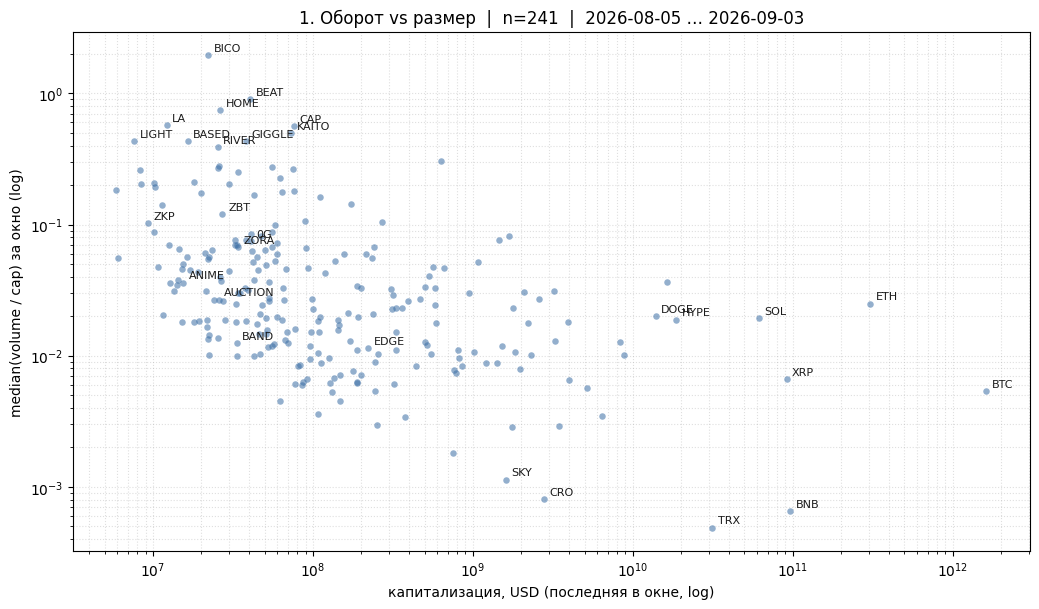

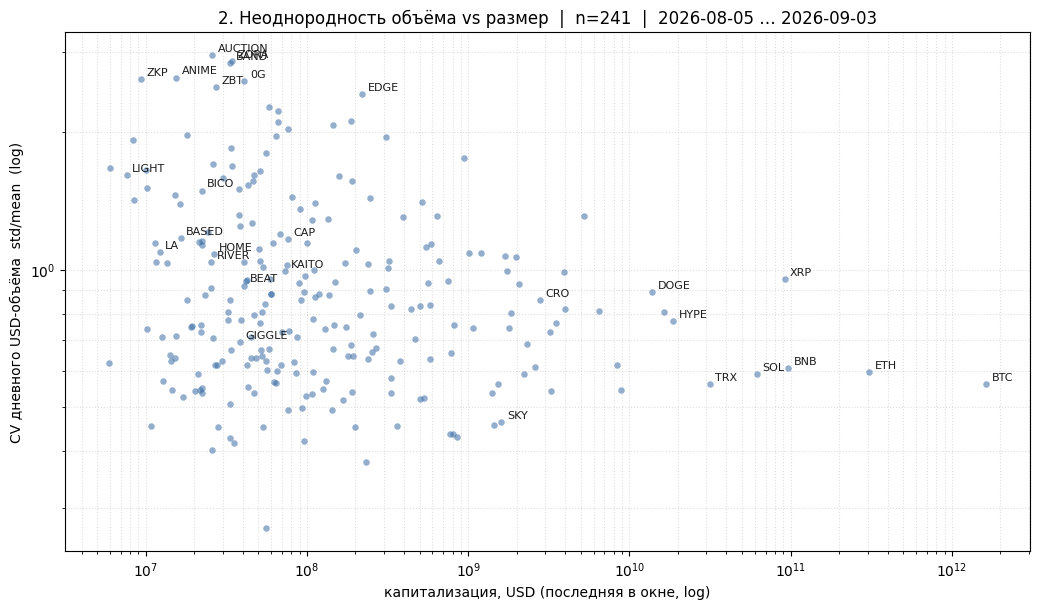

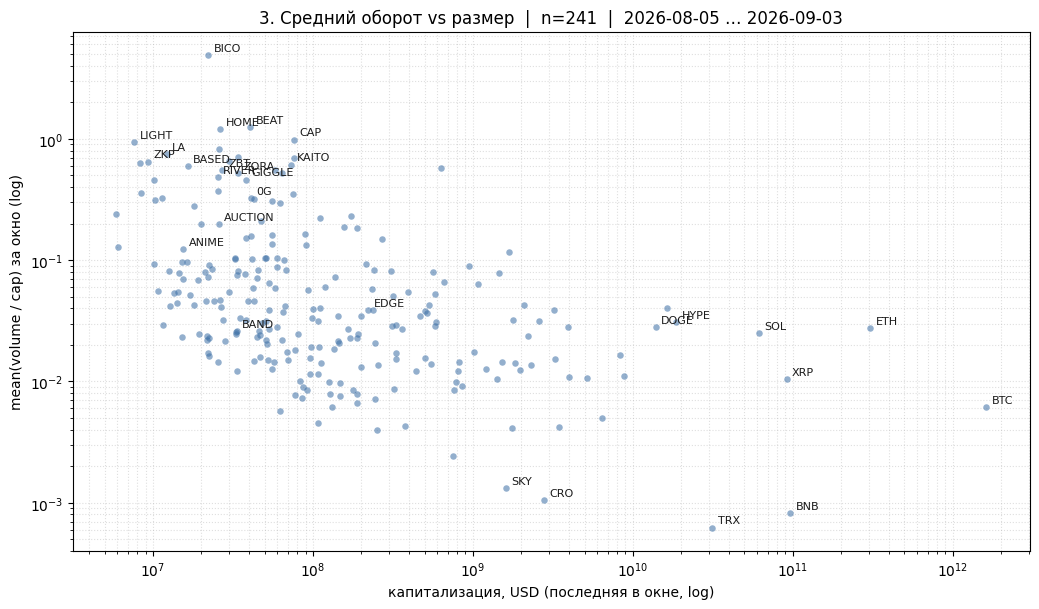

saved /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_cache/figures


In [7]:
ANCHORS = ["BTC", "ETH", "SOL", "BNB", "XRP", "HYPE", "TRX", "DOGE"]


def _label_set(df: pd.DataFrame) -> set[str]:
    names = set(ANCHORS)
    names.update(df.nlargest(10, "median_rel_vol")["base_coin"])
    names.update(df.nlargest(8, "volume_cv")["base_coin"])
    names.update(df.nsmallest(4, "median_rel_vol")["base_coin"])
    return names & set(df["base_coin"])


def scatter_screen(df: pd.DataFrame, y_col: str, y_label: str, title: str, *, log_y: bool = True):
    fig, ax = plt.subplots(figsize=(10.5, 6.2))
    x = df["market_cap_usd"].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    ax.scatter(x, y, s=22, c="#3b6ea5", alpha=0.55, linewidths=0, zorder=2)
    labels = _label_set(df)
    for _, r in df.loc[df["base_coin"].isin(labels)].iterrows():
        ax.annotate(
            r["base_coin"],
            (r["market_cap_usd"], r[y_col]),
            textcoords="offset points",
            xytext=(4, 3),
            fontsize=8,
            color="#1a1a1a",
        )
    ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel("капитализация, USD (последняя в окне, log)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig


n = len(plot_df)
win = f"{WINDOW_START} … {WINDOW_END}"
fig1 = scatter_screen(
    plot_df,
    "median_rel_vol",
    "median(volume / cap) за окно (log)",
    f"1. Оборот vs размер  |  n={n}  |  {win}",
)
fig2 = scatter_screen(
    plot_df,
    "volume_cv",
    "CV дневного USD-объёма  std/mean  (log)",
    f"2. Неоднородность объёма vs размер  |  n={n}  |  {win}",
    log_y=True,
)
fig3 = scatter_screen(
    plot_df,
    "mean_rel_vol",
    "mean(volume / cap) за окно (log)",
    f"3. Средний оборот vs размер  |  n={n}  |  {win}",
)
from IPython.display import display

fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
for name, fig in (("scatter_median_turnover", fig1), ("scatter_volume_cv", fig2), ("scatter_mean_turnover", fig3)):
    fig.savefig(fig_dir / f"{name}.png", dpi=140, bbox_inches="tight")
    display(fig)
plt.close("all")
print("saved", fig_dir)


Интерактив: наведите на точку. Тот же plot-set, те же оси.


In [8]:
try:
    import plotly.express as px
except ImportError:
    print("plotly не установлен — пропускаем hover")
else:
    hover = {
        "gecko_name": True,
        "median_rel_vol": ":.4f",
        "mean_rel_vol": ":.4f",
        "volume_cv": ":.3f",
        "median_volume_usd": ":.3s",
        "n_days_both": True,
        "map_method": True,
    }
    specs = [
        ("median_rel_vol", "median(volume/cap)"),
        ("volume_cv", "CV(volume)"),
        ("mean_rel_vol", "mean(volume/cap)"),
    ]
    for y_col, y_name in specs:
        fig = px.scatter(
            plot_df,
            x="market_cap_usd",
            y=y_col,
            hover_name="base_coin",
            hover_data=hover,
            log_x=True,
            log_y=True,
            title=f"{y_name} vs market cap  (n={len(plot_df)})",
        )
        fig.update_traces(marker=dict(size=8, opacity=0.7))
        fig.update_layout(height=480, margin=dict(l=40, r=20, t=50, b=40))
        fig.show()


## 5. Как читать кластеры (качественно, без порога)

Не финальный фильтр. Ниже — язык для следующего шага, не cutoffs.

| Зона | Типичный вид | Зачем HFT ~100 ms это смотрит |
|------|----------------|-------------------------------|
| мелкие + высокий median turnover | левый верх графика 1 | хайп: оборот большой относительно cap; спреды *могут* быть широкими, но это же зона токсичного flow |
| гиганты + низкий turnover | правый низ графика 1 | BTC/ETH-класс: ликвидность есть, широкий спред из «нет size» маловероятен |
| высокий CV | верх графика 2 | объём дырявый по дням: вчера торговалось, сегодня стакан пустой — опасно путать с устойчивым thin market |
| график 3 ≈ график 1 | mean vs median оборота | если mean ≫ median — редкие всплески объёма тянут среднее; медиана честнее «обычного» дня |

Отдельно: монеты **вне** plot-set. `unmatched` / `missing_market_cap` — это **нет данных**, не «низкая ликвидность». Их нельзя класть в кластер thin-market, пока не закрыт gap.


In [9]:
# mean vs median: где среднее врёт из-за всплесков
tmp = plot_df.copy()
tmp["mean_over_median"] = tmp["mean_rel_vol"] / tmp["median_rel_vol"]
print("mean/median оборот: квантили")
print(tmp["mean_over_median"].quantile([0.5, 0.75, 0.9, 0.95]).round(2).to_string())
print("\nгде mean сильно выше median (всплески объёма):")
display(
    tmp.nlargest(10, "mean_over_median")[
        ["base_coin", "median_rel_vol", "mean_rel_vol", "mean_over_median", "volume_cv", "market_cap_usd"]
    ]
)


mean/median оборот: квантили
0.50    1.37
0.75    1.74
0.90    2.50
0.95    3.18

где mean сильно выше median (всплески объёма):


,base_coin,median_rel_vol,mean_rel_vol,mean_over_median,volume_cv,market_cap_usd
246,ZORA,0.067734,0.521070,7.692867,2.860639,3.422144e+07
28,AUCTION,0.026748,0.196989,7.364626,2.948401,2.572661e+07
245,ZKP,0.102863,0.648859,6.307975,2.609139,9.293486e+06
94,GPS,0.099793,0.555515,5.566646,2.272701,5.838756e+07
220,USELESS,0.033864,0.185333,5.472896,2.112822,1.881313e+08
239,ZBT,0.119811,0.550147,4.591804,2.508948,2.721643e+07
0,0G,0.074988,0.325285,4.337818,2.585146,4.096019e+07
18,APR,0.179824,0.699847,3.891847,2.031990,7.643836e+07
199,SPK,0.026643,0.100000,3.753348,2.104754,6.579382e+07
15,ANIME,0.036119,0.122738,3.398205,2.633395,1.548197e+07


## 6. Производная таблица метрик

Исходный `bybit_okx_universe.csv` **не** переписываем. Ниже — регрессия и калиброванный cap-cutoff (секции 7–9). Это экран tick-load vs редкие спреды, не PnL.

Остаётся открытым: venue min(Bybit, OKX) вместо суммы; hole-rate на lean ticks; denylist `CC`/`F`/`W`/`O` и `CBRS`/`SNXX`.


In [10]:
print("CSV", METRICS_CSV)
print("exists", Path(METRICS_CSV).is_file(), "rows", len(metrics))
print(metrics["status"].value_counts().to_string())
print()
print("колонки:", ", ".join(metrics.columns.astype(str)))


CSV /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_metrics.csv
exists True rows 249
status
ok                     241
missing_market_cap       6
unmatched_coingecko      2

колонки: base_coin, okx_symbol, bybit_symbol, okx_tick_size, okx_lot_size, okx_min_size, bybit_tick_size, bybit_qty_step, bybit_min_order_qty, bybit_min_notional_value, take, gecko_id, gecko_name, map_method, n_candidates, candidate_ids, ticker_volume_usd, ticker_mcap_usd, map_note, n_hist_days, n_days_both, n_days_volume, n_days_mcap, market_cap_usd, median_rel_vol, mean_rel_vol, volume_cv, median_volume_usd, mean_volume_usd, hist_start, hist_end, paprika_id, paprika_name, status, in_plot_set, window_start, window_end


## 7. Log-log регрессия: оборот ~ капитализация

На графике 1 облако в log-log выглядит линейным. Обычная параметризация:

```text
log(median_rel_vol) = a + b · log(market_cap)     # натуральный лог
median_rel_vol      ∝ cap^b                       # степенной закон
```

Обучаем **только plot-set** (n=241, те же точки, что на трёх scatter).  
OLS — канон. Theil–Sen и Huber — диагностика: не заменяют OLS, если их тянут BICO/BEAT.

Это **не** модель прибыльности. Только описание облака, чтобы потом прочитать «типичный оборот при таком cap».


In [11]:
from research.universe_liquidity_lib import (
    CAP_CUTOFF_USD,
    ENTRY_THRESH_PCT,
    FILTERED_CSV,
    OVERVIEW_SUMMARY,
    SPREAD_WINDOW_END,
    SPREAD_WINDOW_START,
    apply_cap_filter,
    attach_loglog_fit,
    filter_counts,
    fit_loglog_huber,
    fit_loglog_ols,
    fit_loglog_theil_sen,
    fitted_turnover_at_cap,
    join_spread_overview,
    save_filtered_csv,
)

ols = fit_loglog_ols(plot_df)
theil = fit_loglog_theil_sen(plot_df)
huber = fit_loglog_huber(plot_df)

print("n =", ols["n"])
print("OLS   ", ols["equation"])
print("       R² =", round(ols["r2"], 4), "  resid_std =", round(ols["resid_std"], 4), "  MAD =", round(ols["resid_mad"], 4))
print("       ", ols["power_law"])
print("Theil–Sen", theil["equation"], "  95% slope", round(theil["b_lo"], 4), "…", round(theil["b_hi"], 4))
print("Huber ", huber["equation"])
print()
print("Интерпретация OLS: b < 0 значит оборот падает с размером (крупные крутятся медленнее относительно cap).")
print("R² умеренный — линия описывает тренд, не монету. Остаток = насколько оборот выше/ниже типичного для этого cap.")
print("Theil–Sen / Huber рядом с OLS → хвост BICO/BEAT линию сильно не утаскивает.")


n = 241
OLS    log(median_rel_vol) = 2.2917 + -0.3146 * log(cap)
       R² = 0.2371   resid_std = 1.1422   MAD = 0.7798
        median_rel_vol ∝ cap^-0.3146
Theil–Sen log(median_rel_vol) = 2.7221 + -0.3533 * log(cap)  (Theil–Sen)   95% slope -0.4425 … -0.2636
Huber  log(median_rel_vol) = 1.3749 + -0.2697 * log(cap)  (Huber)

Интерпретация OLS: b < 0 значит оборот падает с размером (крупные крутятся медленнее относительно cap).
R² умеренный — линия описывает тренд, не монету. Остаток = насколько оборот выше/ниже типичного для этого cap.
Theil–Sen / Huber рядом с OLS → хвост BICO/BEAT линию сильно не утаскивает.


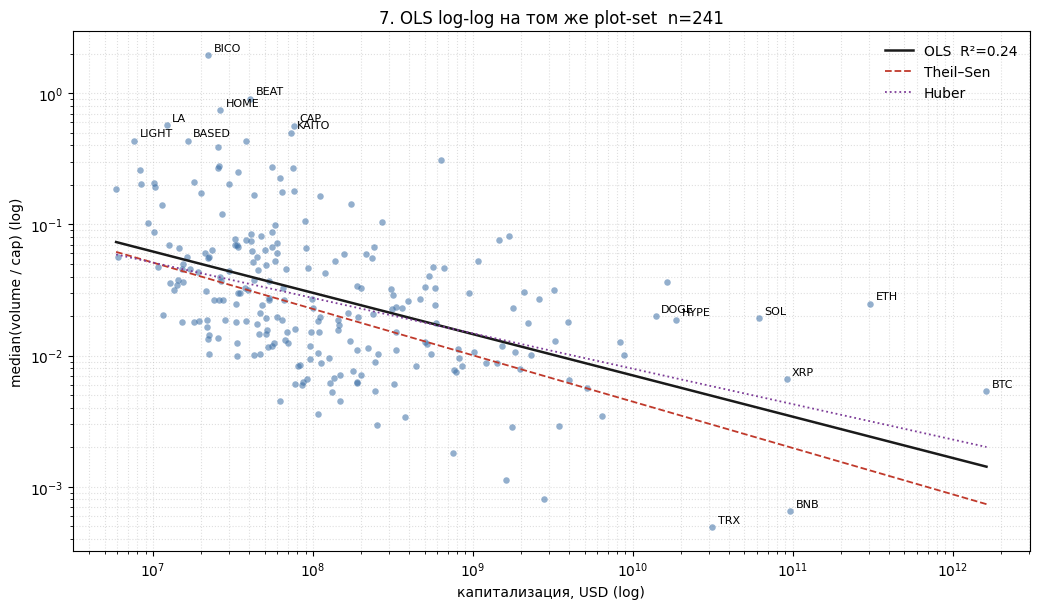

In [12]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(10.5, 6.2))
x = plot_df["market_cap_usd"].to_numpy(dtype=float)
y = plot_df["median_rel_vol"].to_numpy(dtype=float)
ax.scatter(x, y, s=22, c="#3b6ea5", alpha=0.55, linewidths=0, zorder=2)

grid = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
ax.plot(grid, np.exp(ols["a"] + ols["b"] * np.log(grid)), color="#1a1a1a", lw=1.8, label=f"OLS  R²={ols['r2']:.2f}")
ax.plot(grid, np.exp(theil["a"] + theil["b"] * np.log(grid)), color="#c0392b", lw=1.3, ls="--", label="Theil–Sen")
ax.plot(grid, np.exp(huber["a"] + huber["b"] * np.log(grid)), color="#7d3c98", lw=1.3, ls=":", label="Huber")

labels = set(ANCHORS) | set(plot_df.nlargest(8, "median_rel_vol")["base_coin"])
for _, r in plot_df.loc[plot_df["base_coin"].isin(labels)].iterrows():
    ax.annotate(r["base_coin"], (r["market_cap_usd"], r["median_rel_vol"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("капитализация, USD (log)")
ax.set_ylabel("median(volume / cap) (log)")
ax.set_title(f"7. OLS log-log на том же plot-set  n={ols['n']}")
ax.legend(frameon=False)
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "scatter_ols_loglog.png", dpi=140, bbox_inches="tight")
display(fig)
plt.close(fig)


## 8. Калибровка cutoff по августовским спредам

Регрессия **не** задаёт порог cap. Порог читаем из того, где в августе спреды переставали доходить до входа модели.

Источник: [`viz/data/overview_summary.json`](../viz/data/overview_summary.json)  
окно **2026-07-22 … 2026-08-27** (не то же самое, что ликвидность 08-05…09-03 — оба имени ниже).  
338 монет, all-tick p50/p95/p99 `spread_long` / `spread_short` по lean ticks.

**Метрика возможности** (явная):

```text
p99_max = max(p99(spread_long), p99(spread_short))
had_entry_tail  ⇔  p99_max ≥ 0.5%     # VARIATION thresh_open_* в model.ipynb
had_soft_tail   ⇔  p99_max ≥ 0.15%    # только диагностика
```

Это **не** доля времени над порогом и не число сделок. Это «хотя бы 1% тиков был не ниже 0.5%».  
p99=10 в обзоре — overflow гистограммы (`RunningSpreadHist` clip 10); такие значения чистим, не считаем за 10% спред.

Cutoff: **$200M**. Крупнейшая plot-set монета с `had_entry_tail` — `2Z` ≈ $190M. Выше $200M в join **0 / 76** таких монет. Фальсифицируемо: появится p99≥0.5% при cap>$200M — порог неверен.


In [13]:
joined = join_spread_overview(metrics)
joined = attach_loglog_fit(joined, ols)
plot_j = joined.loc[joined["in_plot_set"]].copy()

print("ликвидность", WINDOW_START, "…", WINDOW_END)
print("спреды    ", SPREAD_WINDOW_START, "…", SPREAD_WINDOW_END)
print("overview file", OVERVIEW_SUMMARY, "exists", Path(OVERVIEW_SUMMARY).is_file())
print(f"plot-set {len(plot_j)}  joined p99 {int(plot_j['spread_joined'].sum())}  unjoined {int((~plot_j['spread_joined']).sum())}")
print("unjoined:", ", ".join(plot_j.loc[~plot_j["spread_joined"], "base_coin"].tolist()))
print()

plot_j["log10_cap"] = np.log10(plot_j["market_cap_usd"])
bins = [6, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 13]
plot_j["cap_bin"] = pd.cut(plot_j["log10_cap"], bins)
g = plot_j.groupby("cap_bin", observed=True).agg(
    n=("base_coin", "size"),
    n_joined=("spread_joined", "sum"),
    frac_entry=("had_entry_tail", "mean"),
    frac_soft=("had_soft_tail", "mean"),
    med_p99=("p99_max_clean", "median"),
    med_turn=("median_rel_vol", "median"),
)
print("доля had_entry_tail (p99≥0.5%) по bin log10(cap):")
display(g.round(3))

print()
print("монеты с p99≥0.5% в plot-set (очищенный p99):")
pos = plot_j.loc[plot_j["had_entry_tail"], ["base_coin", "market_cap_usd", "median_rel_vol", "p99_max_clean", "log_residual"]]
display(pos.sort_values("market_cap_usd"))

max_pos = float(pos["market_cap_usd"].max()) if len(pos) else np.nan
print(f"max cap с entry-tail = ${max_pos:,.0f}   cutoff = ${CAP_CUTOFF_USD:,.0f}")
print(f"OLS типичный median(vol/cap) при cutoff: {fitted_turnover_at_cap(ols['a'], ols['b'], CAP_CUTOFF_USD):.4f}")
print(f"выше cutoff: n={(plot_j.market_cap_usd > CAP_CUTOFF_USD).sum()}  entry-tail={int(plot_j.loc[plot_j.market_cap_usd > CAP_CUTOFF_USD, 'had_entry_tail'].fillna(False).sum())}")


ликвидность 2026-08-05 … 2026-09-03
спреды     2026-07-22T11:05:00Z … 2026-08-27T11:40:00Z
overview file /Users/mishatrubik/Desktop/spread/viz/data/overview_summary.json exists True
plot-set 241  joined p99 232  unjoined 9
unjoined: LRC, ZEN, ZETA, ZIL, ZK, ZKP, ZORA, ZRO, ZRX

доля had_entry_tail (p99≥0.5%) по bin log10(cap):


,n,n_joined,frac_entry,frac_soft,med_p99,med_turn
cap_bin,,,,,,
"(6.0, 7.0]",6,5,0.000,0.167,0.139,0.193
"(7.0, 7.5]",50,49,0.120,0.600,0.183,0.046
"(7.5, 8.0]",80,75,0.088,0.425,0.145,0.031
"(8.0, 8.5]",42,41,0.048,0.286,0.119,0.015
"(8.5, 9.0]",28,27,0.000,0.179,0.086,0.016
"(9.0, 9.5]",17,17,0.000,0.000,0.069,0.011
"(9.5, 10.0]",9,9,0.000,0.000,0.053,0.010
"(10.0, 11.0]",7,7,0.000,0.000,0.056,0.019
"(11.0, 13.0]",2,2,0.000,0.000,0.026,0.015



монеты с p99≥0.5% в plot-set (очищенный p99):


,base_coin,market_cap_usd,median_rel_vol,p99_max_clean,log_residual
44,BLEND,1.259487e+07,0.069319,1.093529,0.182744
160,ORDER,1.408834e+07,0.034294,0.567552,-0.485743
41,BICO,2.221150e+07,1.956139,0.825764,3.701239
71,EDEN,2.598247e+07,0.277098,1.041600,1.796216
101,HOME,2.637412e+07,0.743121,2.177776,2.787412
239,ZBT,2.721643e+07,0.119811,0.758491,0.972356
147,MOVE,4.079000e+07,0.084538,0.618382,0.750942
35,BARD,4.282367e+07,0.037799,1.992200,-0.038681
182,RVN,5.115048e+07,0.019344,0.928310,-0.652664
156,ONT,5.568032e+07,0.067369,1.308078,0.621830


max cap с entry-tail = $190,103,406   cutoff = $200,000,000
OLS типичный median(vol/cap) при cutoff: 0.0242
выше cutoff: n=76  entry-tail=0


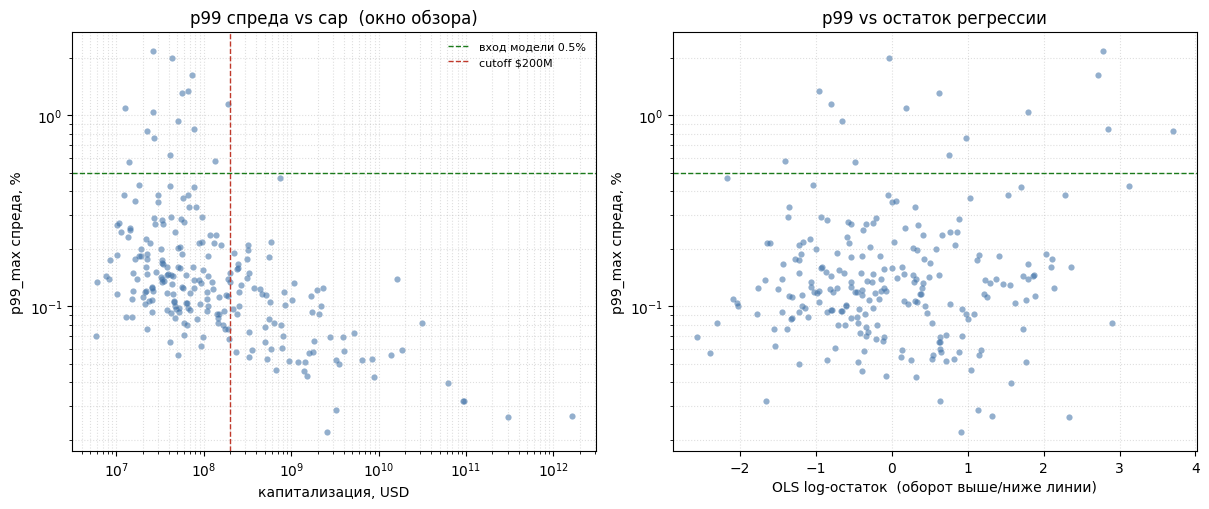

корреляция log_residual vs p99 (joined): 0.197
выше линии (resid>0) frac entry-tail: 0.084 ниже линии: 0.048


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))

ax = axes[0]
sub = plot_j.loc[plot_j["p99_max_clean"].notna()]
ax.scatter(sub["market_cap_usd"], sub["p99_max_clean"], s=20, c="#3b6ea5", alpha=0.55, linewidths=0)
ax.axhline(ENTRY_THRESH_PCT, color="#1a7a1a", ls="--", lw=1, label="вход модели 0.5%")
ax.axvline(CAP_CUTOFF_USD, color="#c0392b", ls="--", lw=1, label=f"cutoff ${CAP_CUTOFF_USD/1e6:.0f}M")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("капитализация, USD")
ax.set_ylabel("p99_max спреда, %")
ax.set_title("p99 спреда vs cap  (окно обзора)")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)

ax = axes[1]
ax.scatter(sub["log_residual"], sub["p99_max_clean"], s=20, c="#3b6ea5", alpha=0.55, linewidths=0)
ax.axhline(ENTRY_THRESH_PCT, color="#1a7a1a", ls="--", lw=1)
ax.set_yscale("log")
ax.set_xlabel("OLS log-остаток  (оборот выше/ниже линии)")
ax.set_ylabel("p99_max спреда, %")
ax.set_title("p99 vs остаток регрессии")
ax.grid(True, which="both", ls=":", alpha=0.4)

fig.tight_layout()
fig.savefig(fig_dir / "spread_p99_vs_cap.png", dpi=140, bbox_inches="tight")
display(fig)
plt.close(fig)

print("корреляция log_residual vs p99 (joined):",
      round(sub[["log_residual", "p99_max_clean"]].corr().iloc[0, 1], 3))
print("выше линии (resid>0) frac entry-tail:",
      round(sub.loc[sub.log_residual > 0, "had_entry_tail"].mean(), 3),
      "ниже линии:",
      round(sub.loc[sub.log_residual <= 0, "had_entry_tail"].mean(), 3))


## 9. Фильтр: выкинуть cap выше cutoff

Правило (только research-derived список):

- **kept** — plot-set и `market_cap_usd ≤ $200M`
- **dropped** — plot-set и cap выше cutoff (гиганты: много тиков, спред ≥0.5% в августе не доходил до p99)
- **held_out** — crypto без валидных метрик (unmatched / нет cap). Не «крупные» и не в considered set, пока нет cap.

`bybit_okx_universe.csv` и `app/bot/**` **не** трогаем. Бот читает исходный CSV для lot/tick (`app/bot/runtime.py`, `app/screaner_b_o.py`); подмена source 345 строк была бы деструктивной. Considered-set — файл ниже.


In [15]:
filtered = apply_cap_filter(joined, cutoff_usd=CAP_CUTOFF_USD)
out_path = save_filtered_csv(filtered)
counts = filter_counts(filtered)
print("crypto → plot-set → dropped_large_cap → kept")
print(f"  {counts['crypto']} → {counts['plot_set']} → drop {counts['dropped_large_cap']} → keep {counts['kept']}")
print(f"  held_out (нет cap / unmatched): {counts['held_out_no_metrics']}")
print("CSV", out_path)
print()
print("типичный OLS оборот при $200M:", round(fitted_turnover_at_cap(ols["a"], ols["b"], CAP_CUTOFF_USD), 4))
print()
print("дропнутые (крупные), по убыванию cap:")
dropped = filtered.loc[filtered["filter_decision"] == "dropped",
                       ["base_coin", "market_cap_usd", "median_rel_vol", "p99_max_clean", "had_entry_tail"]]
display(dropped.sort_values("market_cap_usd", ascending=False).head(25))
print("… всего", len(dropped))
print()
print("held_out:")
display(filtered.loc[filtered["filter_decision"] == "held_out",
                     ["base_coin", "status", "gecko_id", "filter_reason"]])
print()
print("это экран нагрузки тиков vs редкого входа 0.5%. Не утверждение, что kept прибыльны.")
print("source universe и bot routing не менялись.")


crypto → plot-set → dropped_large_cap → kept
  249 → 241 → drop 76 → keep 165
  held_out (нет cap / unmatched): 8
CSV /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_filtered.csv

типичный OLS оборот при $200M: 0.0242

дропнутые (крупные), по убыванию cap:


,base_coin,market_cap_usd,median_rel_vol,p99_max_clean,had_entry_tail
53,BTC,1.630227e+12,0.005346,0.026633,False
81,ETH,3.060639e+11,0.024926,0.026221,False
46,BNB,9.605957e+10,0.000657,0.032037,False
233,XRP,9.171452e+10,0.006666,0.031819,False
195,SOL,6.149796e+10,0.019220,0.039497,False
216,TRX,3.142836e+10,0.000489,0.081478,False
103,HYPE,1.875291e+10,0.018836,0.059178,False
240,ZEC,1.629829e+10,0.036585,0.138655,False
67,DOGE,1.389699e+10,0.020048,0.055660,False
126,LINK,8.825215e+09,0.010118,0.042803,False


… всего 76

held_out:


,base_coin,status,gecko_id,filter_reason
5,ACH,missing_market_cap,alchemy-pay,held_out_no_metrics
48,BOT,unmatched_coingecko,None,held_out_no_metrics
52,BSP,missing_market_cap,bespincoin,held_out_no_metrics
55,CBRS,missing_market_cap,cerebras-systems-robinhood-tokenized-stock,held_out_no_metrics
66,DATA,missing_market_cap,streamr,held_out_no_metrics
95,GRAM,missing_market_cap,gram-2,held_out_no_metrics
189,SHAZ,unmatched_coingecko,None,held_out_no_metrics
194,SNXX,missing_market_cap,td-synnex-xstock,held_out_no_metrics



это экран нагрузки тиков vs редкого входа 0.5%. Не утверждение, что kept прибыльны.
source universe и bot routing не менялись.


## 10. Фильтр по квантилю августовского СКО спреда

**Поиск готового СКО.** Отдельного поля «СКО за всё время» по монете в репо нет.

| Где смотрели | Что есть | Почему это не августовское СКО монеты |
|---|---|---|
| `viz/data/overview_summary.json`, coin pages | all-tick **p50/p95/p99** `spread_long` / `spread_short`, `n_all` | перцентили гистограммы, не std; окно 2026-07-22…08-27 |
| `viz/overview.py` / `CoinAllTickStats` | running histogram (бин 0…10%) | моменты не пишутся |
| `research/universe_liquidity_*` | `volume_cv` = std/mean **дневного USD-объёма** | это не волатильность спреда/цены |
| гир 1.5 / `docs/regime-metrics-v0.md` | `σ_t = rolling_std(volume, W)` | каузальный std объёма внутри бара, не хранится per-coin за август |
| gear 2.2 `sigma0` | window-local MAD спреда в quiet | эксперимент, не вселенная × август |
| `bar_5m` / mid return | локально баров нет (`output/okx_bar5m_hist_regime` пуст) | — |
| `docs/strategy-gears.md`, storage-contract | колонки lean: цены, не `std_*` | спреды считаются при чтении |

**Выбранное определение (посчитано, не прочитано из витрины):**

```
spread_long  = (bybit_bid − okx_ask) / bybit_bid × 100
spread_short = (okx_bid − bybit_ask) / okx_bid × 100
std_spread   = max( std(spread_long), std(spread_short) )   # sample, ddof=1
```

Та же L1-формула, что у overview (без fail-closed). Для арбитража это волатильность **спреда**, не CV объёма и не mid-return.

**Окно:** хотели календарный август 2026-08-01…08-31. На диске lean ticks: 2026-07-22T11:05Z … 2026-08-27T11:40Z, первый августовский файл — **2026-08-03T13:35Z**. Берём доступный август: **2026-08-03T13:35Z … 2026-08-27T11:40Z**. Июль из overview **не** включаем.

Кэш: `research/data/universe_spread_std_august.csv`.  
`n_ticks < 10_000` → `sparse` (не «низкая волатильность»).


In [16]:
import importlib

import research.universe_liquidity_lib as ull

ull = importlib.reload(ull)

from research.universe_liquidity_lib import (
    CAP_CUTOFF_USD,
    FILTERED_CSV,
    METRICS_CSV,
    VOL_FILTERED_CSV,
    VOL_MIN_TICKS,
    VOL_QUANTILE_DEFAULT,
    VOL_QUANTILES,
    VOL_STD_CSV,
    VOL_WINDOW_END,
    VOL_WINDOW_START,
    apply_vol_quantile_filter,
    compute_august_spread_std,
    join_august_spread_std,
    save_vol_filtered_csv,
    std_quantiles,
    vol_cap_venn,
    vol_window_spec,
)

spec = vol_window_spec()
print("определение:", spec["definition"])
print("окно", spec["window_start"], "…", spec["window_end"])
print(spec["calendar_note"])
print("min_ticks (sparse ≠ low vol):", spec["min_ticks"])

# кэш, если уже посчитан; иначе один проход по lean ticks (~60 ГБ August)
std_df = compute_august_spread_std(force=False)
print()
print("монет в кэше СКО:", len(std_df), "файлов:", int(std_df["n_files"].iloc[0]) if "n_files" in std_df else "?")
print("std_status:", std_df["std_status"].value_counts().to_dict())
print("окно в CSV:", std_df["window_start"].iloc[0], "…", std_df["window_end"].iloc[0])
print("CSV", VOL_STD_CSV)
print()
print(std_df[["base_coin", "n_ticks", "days_with_ticks", "std_spread", "std_status"]]
      .sort_values("std_spread").head(8).to_string(index=False))


определение: sample std (ddof=1) of all-tick spread_long / spread_short in percent; std_spread = max(std_long, std_short). Same L1 formula as overview (no fail-closed). Not volume_cv, not gear-1.5 rolling volume sigma, not gear-2.2 quiet-window MAD/sigma0.
окно 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z
Wanted calendar August 2026-08-01..08-31. Disk has 2026-07-22T11:05Z..2026-08-27T11:40Z; first August file is 2026-08-03T13:35Z. Window is available August ticks only.
min_ticks (sparse ≠ low vol): 10000

монет в кэше СКО: 336 файлов: 6094
std_status: {'ok': 336}
окно в CSV: 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z
CSV /Users/mishatrubik/Desktop/spread/research/data/universe_spread_std_august.csv

base_coin  n_ticks  days_with_ticks  std_spread std_status
      BTC 46390074               25    0.009713         ok
      ETH 46978316               25    0.010897         ok
      SOL 35173288               25    0.016433         ok
      XRP 37738938               25    0.017720       

Распределение `std_spread` по монетам, у которых хватает тиков (`std_status==ok`). Пропуски и sparse отдельно: их нельзя класть в левый хвост «неволатильных».


lean ticks: 336 монет, все std_status=ok (min n_ticks=921683)
plot-set: 241   из них со СКО: 232   missing: 9
  missing (нет в lean за окно): LRC, ZEN, ZETA, ZIL, ZK, ZKP, ZORA, ZRO, ZRX
квантили std_spread на plot-set (%):
   q10  0.03584
   q20  0.04697
   q25  0.05170
   q50  0.06983
  min  0.00971   max 0.42774   median 0.06983

кандидат cutoff: Q20 = 0.04697 %  (дропаем std_spread < cutoff)
gap не используем.


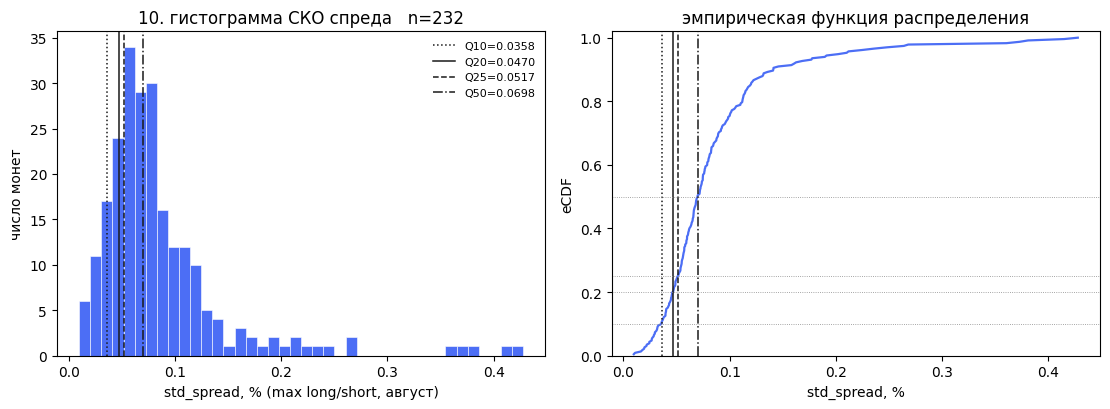

saved /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_cache/figures/std_spread_august_hist.png


In [17]:
# Квантили и гистограмма — по plot-set (crypto с метриками), не по equity в lean.
if "filtered" in globals() and isinstance(filtered, pd.DataFrame) and "in_plot_set" in filtered.columns:
    _cap = filtered
else:
    _cap = pd.read_csv(FILTERED_CSV)
_plot_coins = set(_cap.loc[_cap["in_plot_set"] == True, "base_coin"].astype(str).str.upper())
std_plot = std_df.loc[std_df["base_coin"].isin(_plot_coins)].copy()
ok_std = std_plot.loc[std_plot["std_status"] == "ok", "std_spread"].astype(float)
missing_plot = sorted(_plot_coins - set(std_df["base_coin"]))
qs = std_quantiles(ok_std, VOL_QUANTILES)
print(f"lean ticks: {len(std_df)} монет, все std_status=ok (min n_ticks={int(std_df['n_ticks'].min())})")
print(f"plot-set: {len(_plot_coins)}   из них со СКО: {len(ok_std)}   missing: {len(missing_plot)}")
if missing_plot:
    print("  missing (нет в lean за окно):", ", ".join(missing_plot))
print("квантили std_spread на plot-set (%):")
for k, v in qs.items():
    print(f"  {k:>4}  {v:.5f}")
print(f"  min  {ok_std.min():.5f}   max {ok_std.max():.5f}   median {ok_std.median():.5f}")

# Гистограмма одномодальная, правый скос; разрыва в левом хвосте нет
# (макс. gap ниже медианы — ETH→SOL, кластер гигантов, не «дыра»).
# Значит дефолт: Q20, не gap.
vol_q = VOL_QUANTILE_DEFAULT
vol_cut = qs[f"q{int(vol_q * 100)}"]
print(f"\nкандидат cutoff: Q{int(vol_q*100)} = {vol_cut:.5f} %  (дропаем std_spread < cutoff)")
print("gap не используем.")

fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
ax = axes[0]
ax.hist(ok_std, bins=40, color="#4c6ef5", edgecolor="white", linewidth=0.4)
for name, val, ls in (
    ("Q10", qs["q10"], ":"),
    ("Q20", qs["q20"], "-"),
    ("Q25", qs["q25"], "--"),
    ("Q50", qs["q50"], "-."),
):
    ax.axvline(val, color="#1a1a1a", ls=ls, lw=1.1, label=f"{name}={val:.4f}")
ax.set_xlabel("std_spread, % (max long/short, август)")
ax.set_ylabel("число монет")
ax.set_title(f"10. гистограмма СКО спреда   n={len(ok_std)}")
ax.legend(fontsize=8, frameon=False)

ax = axes[1]
xs = np.sort(ok_std.to_numpy())
ys = np.arange(1, len(xs) + 1) / len(xs)
ax.plot(xs, ys, color="#4c6ef5", lw=1.6)
for name, val, ls in (
    ("Q10", qs["q10"], ":"),
    ("Q20", qs["q20"], "-"),
    ("Q25", qs["q25"], "--"),
    ("Q50", qs["q50"], "-."),
):
    ax.axvline(val, color="#1a1a1a", ls=ls, lw=1.1)
    ax.axhline({"Q10": 0.10, "Q20": 0.20, "Q25": 0.25, "Q50": 0.50}[name],
               color="#888", ls=":", lw=0.6)
ax.set_xlabel("std_spread, %")
ax.set_ylabel("eCDF")
ax.set_title("эмпирическая функция распределения")
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(fig_dir / "std_spread_august_hist.png", dpi=140, bbox_inches="tight")
plt.show()
print("saved", fig_dir / "std_spread_august_hist.png")


Гистограмма одномодальная со скосом вправо: мода около 0.06%, гиганты (BTC/ETH) в левом хвосте, дырки нет. Максимальный gap ниже медианы — шаг ETH→SOL, это кластер крупных, не разрыв смеси.

Поэтому порог — **Q20 plot-set ≈ 0.047%**, не gap. Q10 отсекает почти только гигантов; Q25 близко к Q20. Это exploratory, не «правильный» квантиль.

9 монет plot-set без тиков в окне (`LRC ZEN ZETA ZIL ZK ZKP ZORA ZRO ZRX`) — **missing**, не low-vol.

Дальше: пересечение с `cap > $200M` на том же plot-set.


In [18]:
from IPython.display import display

# plot-set / cap-фильтр из предыдущих ячеек или с диска — не пересчитываем ликвидность
if "filtered" in globals() and isinstance(filtered, pd.DataFrame) and "filter_decision" in filtered.columns:
    cap_df = filtered.copy()
else:
    cap_df = pd.read_csv(FILTERED_CSV)
    print("loaded cap filter from", FILTERED_CSV)

joined_vol = join_august_spread_std(cap_df, std_df)
joined_vol = apply_vol_quantile_filter(joined_vol, q=vol_q, cutoff=vol_cut)

venn = vol_cap_venn(joined_vol)
print("окно СКО", VOL_WINDOW_START, "…", VOL_WINDOW_END)
print(f"cutoff Q{int(vol_q*100)} = {vol_cut:.5f} %")
print()
print("Venn на plot-set (cap>$200M  ×  std<Q20):")
print(f"  plot-set                         {venn['plot_set']}")
print(f"  dropped cap only                 {venn['dropped_cap_only']}")
print(f"  dropped vol only (низкое СКО)    {venn['dropped_vol_only']}")
print(f"  dropped both                     {venn['dropped_both']}")
print(f"  kept both                        {venn['kept_both']}")
print(f"  held_out std на plot-set         {venn['held_out_std_on_plot_set']}")
print()
print(f"cap dropped (plot-set): {venn['cap_dropped']}    vol dropped (plot-set): {venn['vol_dropped']}")

# пропуски СКО среди crypto / plot-set
crypto_n = len(joined_vol)
plot = joined_vol["in_plot_set"].fillna(False)
print()
print("missing vs sparse vs ok (все crypto-строки фильтра):")
print(joined_vol["std_status"].value_counts(dropna=False).to_string())
print("plot-set без usable std:", int((plot & ~joined_vol["std_usable"].fillna(False)).sum()))

vol_path = save_vol_filtered_csv(joined_vol)
print()
print("derived CSV", vol_path)
print("source bybit_okx_universe.csv и bot files не трогали")

cols = ["base_coin", "market_cap_usd", "std_spread", "filter_decision", "vol_filter_decision"]
print()
print("дроп только по СКО (cap kept, vol dropped), наименее волатильные:")
only_vol = joined_vol.loc[
    (joined_vol["filter_decision"] == "kept") & (joined_vol["vol_filter_decision"] == "dropped"),
    cols,
].sort_values("std_spread")
display(only_vol.head(20))
print("… всего", len(only_vol))
print()
print("прошли оба фильтра (kept_both), топ СКО:")
both = joined_vol.loc[
    (joined_vol["filter_decision"] == "kept") & (joined_vol["vol_filter_decision"] == "kept"),
    cols,
].sort_values("std_spread", ascending=False)
display(both.head(12))
print("… всего", len(both))


окно СКО 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z
cutoff Q20 = 0.04697 %

Venn на plot-set (cap>$200M  ×  std<Q20):
  plot-set                         241
  dropped cap only                 34
  dropped vol only (низкое СКО)    6
  dropped both                     41
  kept both                        151
  held_out std на plot-set         9

cap dropped (plot-set): 76    vol dropped (plot-set): 47

missing vs sparse vs ok (все crypto-строки фильтра):
std_status
ok         240
missing      9
plot-set без usable std: 9

derived CSV /Users/mishatrubik/Desktop/spread/research/data/universe_vol_quantile_filtered.csv
source bybit_okx_universe.csv и bot files не трогали

дроп только по СКО (cap kept, vol dropped), наименее волатильные:


,base_coin,market_cap_usd,std_spread,filter_decision,vol_filter_decision
16,APE,1.427318e+08,0.040004,kept,dropped
176,RE,7.492178e+07,0.042960,kept,dropped
14,ALLO,6.202160e+07,0.043733,kept,dropped
73,EGLD,1.443328e+08,0.045442,kept,dropped
31,AXS,1.670018e+08,0.045783,kept,dropped
133,MANA,1.474410e+08,0.046928,kept,dropped


… всего 6

прошли оба фильтра (kept_both), топ СКО:


,base_coin,market_cap_usd,std_spread,filter_decision,vol_filter_decision
115,KAITO,7.339523e+07,0.427740,kept,kept
101,HOME,2.637412e+07,0.414827,kept,kept
224,WAL,6.660717e+07,0.380967,kept,kept
182,RVN,5.115048e+07,0.372988,kept,kept
156,ONT,5.568032e+07,0.360461,kept,kept
2,2Z,1.901034e+08,0.268110,kept,kept
41,BICO,2.221150e+07,0.263973,kept,kept
100,HMSTR,1.142519e+07,0.248449,kept,kept
54,CAP,7.657272e+07,0.235644,kept,kept
44,BLEND,1.259487e+07,0.224484,kept,kept


… всего 151


**Оговорки.** Низкое СКО спреда ≠ «не будет дыр»: редкий hole может сидеть в хвосте, который std почти не двигает. Высокое СКО ≠ торгуемость: широкий шум, дырявый стакан, equity-коллизии. Это tick/regime-экран, не PnL. `volume_cv` сюда не подставляли.


## 11. Облако СКО × капитализация (log-log)

Та же интуиция, что у оборота: в log-log крупнее монета — тише спред. Берём уже посчитанное августовское `std_spread` и cap plot-set. Тики заново не сканируем.

```text
log(std_spread) = a + b · log(market_cap)     # натуральный лог, OLS
std_spread      ∝ cap^b
```

Точки: plot-set с usable СКО (n≈232). Девять Z* без тиков — missing, не «низкая волатильность», на график не ставим.

OLS — канон (`np.polyfit`, intercept, без весов, in-sample R² в лог-пространстве). Theil–Sen / Huber — пунктир. Новый cutoff с этой линии **не** режем: смотрим, есть ли степенной закон.


In [19]:
import importlib

import research.universe_liquidity_lib as ull

ull = importlib.reload(ull)
from research.universe_liquidity_lib import (
    FILTERED_CSV,
    VOL_WINDOW_END,
    VOL_WINDOW_START,
    compute_august_spread_std,
    fit_loglog_huber_xy,
    fit_loglog_ols_xy,
    fit_loglog_theil_sen_xy,
    join_august_spread_std,
)

if "std_df" not in globals() or not isinstance(std_df, pd.DataFrame):
    std_df = compute_august_spread_std(force=False)
if "filtered" in globals() and isinstance(filtered, pd.DataFrame) and "in_plot_set" in filtered.columns:
    cap_src = filtered
else:
    cap_src = pd.read_csv(FILTERED_CSV)

std_cap = join_august_spread_std(cap_src, std_df)
plot_std = std_cap.loc[std_cap["in_plot_set"].astype(bool)].copy()
missing_std = plot_std.loc[~plot_std["std_usable"].fillna(False), "base_coin"].astype(str).tolist()
cloud = plot_std.loc[
    plot_std["std_usable"].fillna(False)
    & np.isfinite(plot_std["market_cap_usd"])
    & (plot_std["market_cap_usd"] > 0)
    & np.isfinite(plot_std["std_spread"])
    & (plot_std["std_spread"] > 0)
].copy()

ols_std = fit_loglog_ols_xy(cloud, y_col="std_spread", y_name="std_spread")
theil_std = fit_loglog_theil_sen_xy(cloud, y_col="std_spread", y_name="std_spread")
huber_std = fit_loglog_huber_xy(cloud, y_col="std_spread", y_name="std_spread")

print("окно СКО", VOL_WINDOW_START, "…", VOL_WINDOW_END)
print(f"plot-set {int(plot_std['in_plot_set'].sum())}  на графике {ols_std['n']}  missing std {len(missing_std)}")
if missing_std:
    print("  missing:", ", ".join(sorted(missing_std)))
print("OLS   ", ols_std["equation"])
print("      ", ols_std["power_law"], f"  R²(log)={ols_std['r2']:.4f}")
print("Theil ", theil_std["equation"])
print("Huber ", huber_std["equation"])
print()
print("для сравнения оборот~cap:  log(median_rel_vol) = 2.2917 − 0.3146 · log(cap)  R²=0.237  n=241")
print(f"СКО~cap слабее по наклону ({ols_std['b']:.3f} vs −0.315), но облако теснее (R² {ols_std['r2']:.2f} vs 0.24).")
print("Theil–Sen / Huber рядом с OLS → хвост KAITO/HOME линию сильно не утаскивает.")
print("Это описание облака, не торговый закон и не новый фильтр.")


окно СКО 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z
plot-set 241  на графике 232  missing std 9
  missing: LRC, ZEN, ZETA, ZIL, ZK, ZKP, ZORA, ZRO, ZRX
OLS    log(std_spread) = 1.1501 + -0.2026 * log(cap)
       std_spread ∝ cap^-0.2026   R²(log)=0.4728
Theil  log(std_spread) = 0.8457 + -0.1932 * log(cap)  (Theil–Sen)
Huber  log(std_spread) = 0.9378 + -0.1952 * log(cap)  (Huber)

для сравнения оборот~cap:  log(median_rel_vol) = 2.2917 − 0.3146 · log(cap)  R²=0.237  n=241
СКО~cap слабее по наклону (-0.203 vs −0.315), но облако теснее (R² 0.47 vs 0.24).
Theil–Sen / Huber рядом с OLS → хвост KAITO/HOME линию сильно не утаскивает.
Это описание облака, не торговый закон и не новый фильтр.


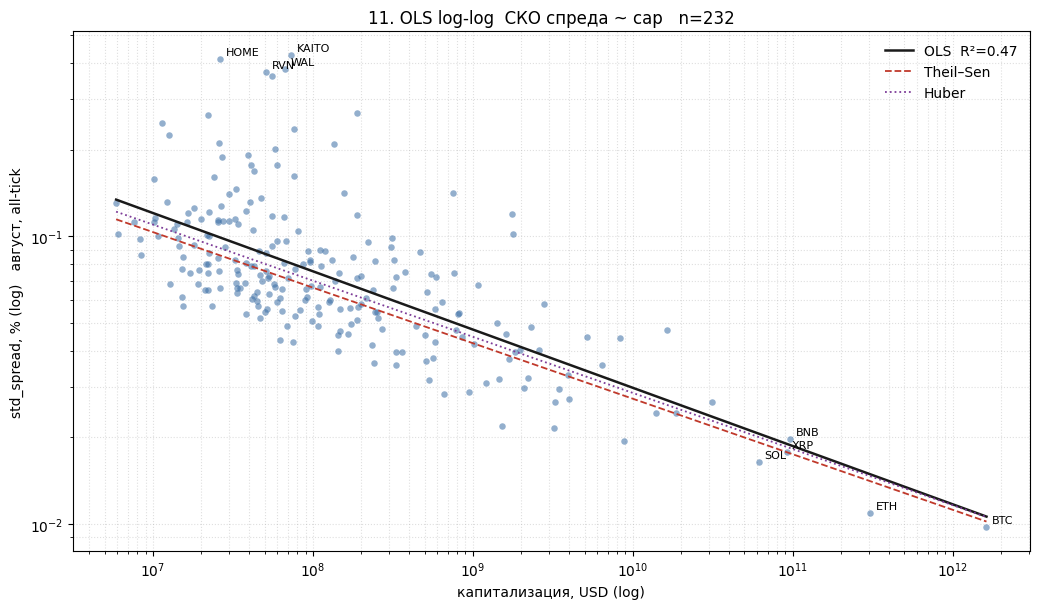

saved /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_cache/figures/scatter_std_vs_cap_loglog.png


In [20]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(10.5, 6.2))
x = cloud["market_cap_usd"].to_numpy(dtype=float)
y = cloud["std_spread"].to_numpy(dtype=float)
ax.scatter(x, y, s=22, c="#3b6ea5", alpha=0.55, linewidths=0, zorder=2)

grid = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
ax.plot(grid, np.exp(ols_std["a"] + ols_std["b"] * np.log(grid)),
        color="#1a1a1a", lw=1.8, label=f"OLS  R²={ols_std['r2']:.2f}")
ax.plot(grid, np.exp(theil_std["a"] + theil_std["b"] * np.log(grid)),
        color="#c0392b", lw=1.3, ls="--", label="Theil–Sen")
ax.plot(grid, np.exp(huber_std["a"] + huber_std["b"] * np.log(grid)),
        color="#7d3c98", lw=1.3, ls=":", label="Huber")

anchors = ["BTC", "ETH", "SOL", "BNB", "XRP"]
hi = set(cloud.nlargest(4, "std_spread")["base_coin"])
labels = set(anchors) | hi
for _, r in cloud.loc[cloud["base_coin"].isin(labels)].iterrows():
    ax.annotate(r["base_coin"], (r["market_cap_usd"], r["std_spread"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("капитализация, USD (log)")
ax.set_ylabel("std_spread, % (log)   август, all-tick")
ax.set_title(f"11. OLS log-log  СКО спреда ~ cap   n={ols_std['n']}")
ax.legend(frameon=False)
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "scatter_std_vs_cap_loglog.png", dpi=140, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved", fig_dir / "scatter_std_vs_cap_loglog.png")


**Как читать.** Наклон отрицательный: крупнее cap — меньше pooled СКО спреда. Степенной закон слабее, чем у оборота (`b ≈ −0.20` против `−0.31`), но R² выше (`0.47` против `0.24`): размер лучше предсказывает тишину спреда, чем оборот.

Theil–Sen / Huber почти совпадают с OLS — не артефакт KAITO/HOME. Облако сплошное, разрыва нет: **новый cutoff с этой линии не ставим.** Q20 по одномерному СКО (§10) и порог $200M остаются отдельными экранами.

Pooled August std глушит редкие дыры. Корреляция cap↔СКО — не торговое правило.


## 12. Совместный фильтр: тихо **и** крупно

Методика зафиксирована (не переоткрываем дизайн).

Одномерный Q20 по СКО переобучается на «тихий август» у мелких. Жёсткий $200M режет всех гигантов, даже шумных. Совместное правило:

1. Единственный свободный порог — эмпирический **Q25** `std_spread` на том же 232-coin plot-set, что OLS §11.
2. `std_spread` и OLS — в **процентах** (не доли): `0.05` = 0.05%, не 5%.
3. Из `ln(std) = a + b·ln(cap)` инверсия: `cap* = exp((a − ln(Q25)) / (−b))`.
4. **Дропаем iff** `std < Q25` **и** `cap > cap*`.
5. Оставляем: тихое-но-мелкое (август мог быть сонным) и крупное-но-шумное.
6. Нет СКО (Z*) — `held_out`, не quiet.

Это compute-экран тиков, не PnL.

**Канон дальше — §13:** пользователь решил, что в large-but-noisy «нет потенциала». Там жёсткий cut `cap > cap*` (не AND по std). Этот §12 остаётся историей AND-правила; CSV `universe_joint_q25_filtered.csv` не перезаписываем.



In [21]:
import importlib

import research.universe_liquidity_lib as ull

ull = importlib.reload(ull)
from research.universe_liquidity_lib import (
    CAP_CUTOFF_USD,
    FILTERED_CSV,
    JOINT_FILTERED_CSV,
    JOINT_STD_QUANTILE,
    VOL_QUANTILE_DEFAULT,
    VOL_WINDOW_END,
    VOL_WINDOW_START,
    apply_joint_q25_filter,
    apply_vol_quantile_filter,
    compute_august_spread_std,
    fit_loglog_ols_xy,
    join_august_spread_std,
    joint_filter_counts,
    joint_sensitivity_table,
    joint_threshold_from_ols,
    joint_vs_old_screens,
    save_joint_filtered_csv,
    std_quantiles,
)

if "std_df" not in globals() or not isinstance(std_df, pd.DataFrame):
    std_df = compute_august_spread_std(force=False)
if "filtered" in globals() and isinstance(filtered, pd.DataFrame) and "in_plot_set" in filtered.columns:
    cap_src = filtered
else:
    cap_src = pd.read_csv(FILTERED_CSV)

base = join_august_spread_std(cap_src, std_df)
plot_jnt = base.loc[base["in_plot_set"].astype(bool)].copy()
cloud_jnt = plot_jnt.loc[
    plot_jnt["std_usable"].fillna(False)
    & np.isfinite(plot_jnt["market_cap_usd"])
    & (plot_jnt["market_cap_usd"] > 0)
    & np.isfinite(plot_jnt["std_spread"])
    & (plot_jnt["std_spread"] > 0)
].copy()

ols_jnt = fit_loglog_ols_xy(cloud_jnt, y_col="std_spread", y_name="std_spread")
spec = joint_threshold_from_ols(cloud_jnt, q=JOINT_STD_QUANTILE, ols=ols_jnt)
print("единицы std_spread: проценты  (0.05 = 0.05%, та же шкала, что OLS §11)")
print("OLS", ols_jnt["equation"], f"  R²={ols_jnt['r2']:.4f}  n={ols_jnt['n']}")
print(f"§11 справка: log(std)=1.1501 − 0.2026·log(cap). Сдвиг a={ols_jnt['a']-1.1501:+.6f}  b={ols_jnt['b']+0.2026:+.6f}")
print(f"Q25 = {spec['q_std']:.6f} %")
print(f"cap* = ${spec['cap_star_usd']:,.0f}")
print(f"проверка: OLS(cap*) = {spec['pred_std_at_cap_star']:.6f} %  (должно ≈ Q25)")
print("окно СКО", VOL_WINDOW_START, "…", VOL_WINDOW_END)
print(f"crypto {len(base)}  plot-set {int(plot_jnt['in_plot_set'].sum())}  std-usable {len(cloud_jnt)}")


единицы std_spread: проценты  (0.05 = 0.05%, та же шкала, что OLS §11)
OLS log(std_spread) = 1.1501 + -0.2026 * log(cap)   R²=0.4728  n=232
§11 справка: log(std)=1.1501 − 0.2026·log(cap). Сдвиг a=+0.000022  b=-0.000002
Q25 = 0.051699 %
cap* = $653,682,245
проверка: OLS(cap*) = 0.051699 %  (должно ≈ Q25)
окно СКО 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z
crypto 249  plot-set 241  std-usable 232


In [22]:
from IPython.display import display

# Q20 на plot-set — тот же экран §10, только чтобы сравнить счётчики
q20_plot = float(cloud_jnt["std_spread"].quantile(VOL_QUANTILE_DEFAULT))
with_old = apply_vol_quantile_filter(base, q=VOL_QUANTILE_DEFAULT, cutoff=q20_plot)
joint = apply_joint_q25_filter(with_old, spec=spec)
counts = joint_filter_counts(joint)
print("quiet (std < Q25):", counts["n_quiet"])
print("large (cap > cap*):", counts["n_large"])
print("dropped = quiet ∧ large:", counts["dropped"])
print("kept (plot-set usable, не rectangle):", counts["kept"])
print("held_out всего / на plot-set:", counts["held_out"], "/", counts["held_out_on_plot_set"])
print(f"crypto {counts['crypto']} / plot-set {counts['plot_set']} / std-usable {counts['std_usable']}")

dropped = joint.loc[joint["joint_filter_decision"] == "dropped"].sort_values("market_cap_usd", ascending=False)
print()
print("дропнутые (тихие гиганты):")
display(dropped[["base_coin", "market_cap_usd", "std_spread", "p99_max_clean", "had_entry_tail"]])
print("тикеры:", ", ".join(dropped["base_coin"].astype(str).tolist()))

entry = joint.loc[joint.get("had_entry_tail", False).fillna(False)]
entry_drop = entry.loc[entry["joint_filter_decision"] == "dropped", "base_coin"]
print()
print(f"had_entry_tail (p99≥0.5%) в crypto: {int(len(entry))}")
print("из них в joint-drop:", ", ".join(entry_drop.astype(str)) if len(entry_drop) else "нет")


quiet (std < Q25): 58
large (cap > cap*): 43
dropped = quiet ∧ large: 35
kept (plot-set usable, не rectangle): 197
held_out всего / на plot-set: 17 / 9
crypto 249 / plot-set 241 / std-usable 232

дропнутые (тихие гиганты):


,base_coin,market_cap_usd,std_spread,p99_max_clean,had_entry_tail
53,BTC,1.630227e+12,0.009713,0.026633,False
81,ETH,3.060639e+11,0.010897,0.026221,False
46,BNB,9.605957e+10,0.019726,0.032037,False
233,XRP,9.171452e+10,0.017720,0.031819,False
195,SOL,6.149796e+10,0.016433,0.039497,False
216,TRX,3.142836e+10,0.026626,0.081478,False
103,HYPE,1.875291e+10,0.024328,0.059178,False
240,ZEC,1.629829e+10,0.047326,0.138655,False
67,DOGE,1.389699e+10,0.024349,0.055660,False
126,LINK,8.825215e+09,0.019415,0.042803,False


тикеры: BTC, ETH, BNB, XRP, SOL, TRX, HYPE, ZEC, DOGE, LINK, ADA, XLM, BCH, LTC, UNI, HBAR, AVAX, SUI, NEAR, OKB, TAO, AAVE, ASTER, WLFI, ENA, SKY, DOT, WLD, ICP, ETC, POL, ARB, ALGO, JUP, FIL

had_entry_tail (p99≥0.5%) в crypto: 15
из них в joint-drop: нет


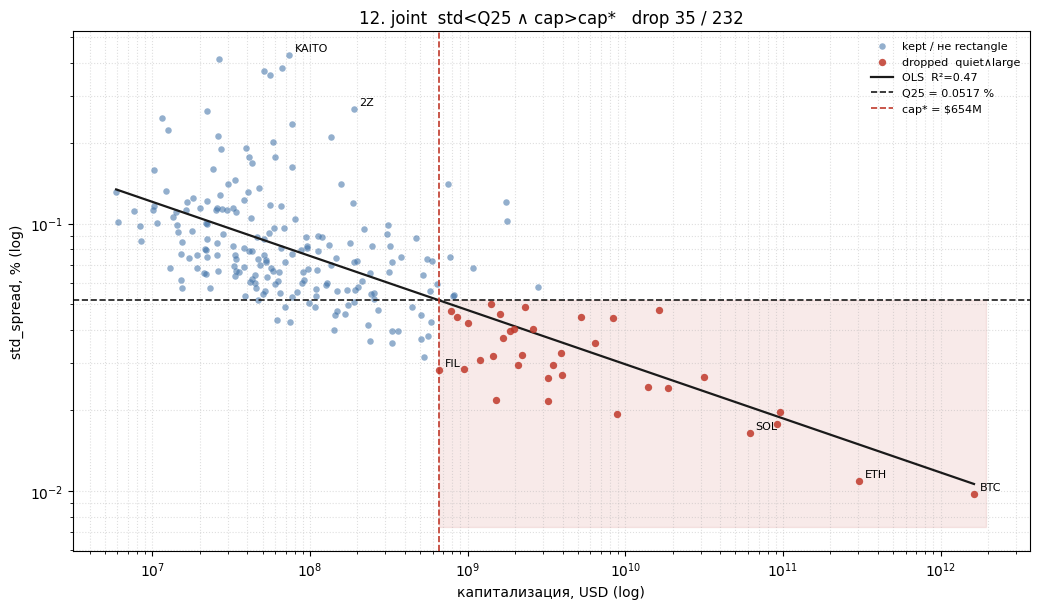

saved /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_cache/figures/scatter_joint_q25_capstar.png


In [23]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(10.5, 6.2))
x = cloud_jnt["market_cap_usd"].to_numpy(dtype=float)
y = cloud_jnt["std_spread"].to_numpy(dtype=float)
dropped_set = set(dropped["base_coin"].astype(str))
is_drop = cloud_jnt["base_coin"].astype(str).isin(dropped_set)

ax.scatter(x[~is_drop], y[~is_drop], s=22, c="#3b6ea5", alpha=0.55, linewidths=0, zorder=2, label="kept / не rectangle")
ax.scatter(x[is_drop], y[is_drop], s=28, c="#c0392b", alpha=0.85, linewidths=0, zorder=3, label="dropped  quiet∧large")

grid = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
ax.plot(grid, np.exp(ols_jnt["a"] + ols_jnt["b"] * np.log(grid)),
        color="#1a1a1a", lw=1.6, label=f"OLS  R²={ols_jnt['r2']:.2f}")
ax.axhline(spec["q_std"], color="#1a1a1a", ls="--", lw=1.2, label=f"Q25 = {spec['q_std']:.4f} %")
ax.axvline(spec["cap_star_usd"], color="#c0392b", ls="--", lw=1.2,
           label=f"cap* = ${spec['cap_star_usd']/1e6:.0f}M")

xs_rect = np.logspace(np.log10(spec["cap_star_usd"]), np.log10(x.max() * 1.2), 40)
ax.fill_between(xs_rect, y.min() * 0.75, spec["q_std"], color="#c0392b", alpha=0.10, zorder=0)

anchors = ["BTC", "ETH", "SOL", "FIL", "2Z", "KAITO"]
for _, r in cloud_jnt.loc[cloud_jnt["base_coin"].isin(anchors)].iterrows():
    ax.annotate(r["base_coin"], (r["market_cap_usd"], r["std_spread"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("капитализация, USD (log)")
ax.set_ylabel("std_spread, % (log)")
ax.set_title(f"12. joint  std<Q25 ∧ cap>cap*   drop {counts['dropped']} / {ols_jnt['n']}")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "scatter_joint_q25_capstar.png", dpi=140, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved", fig_dir / "scatter_joint_q25_capstar.png")


In [24]:
sens = joint_sensitivity_table(cloud_jnt, qs=(0.20, 0.25, 0.30), ols=ols_jnt)
print("чувствительность (не новые фильтры — те же a,b):")
display(sens.assign(
    cap_star_usd=sens["cap_star_usd"].map(lambda v: f"${v:,.0f}"),
    q_std_pct=sens["q_std_pct"].map(lambda v: f"{v:.5f}"),
))
print("мелкий |b|≈0.20: сдвиг Q20→Q30 гоняет cap* примерно вдвое ($1.05B → $464M). Q25 — компромисс, не «устойчивая» точка.")

ov = joint_vs_old_screens(joint)
print()
print("пересечение счётчиков на plot-set:")
print(f"  joint drop {ov['joint_dropped']}   cap>$200M drop {ov['cap200_dropped']}   std<Q20 drop {ov['vol_q20_dropped']}")
print(f"  joint ∩ $200M: {ov['joint_and_cap200']}   только $200M: {ov['cap200_only_vs_joint']}   только joint: {ov['joint_only_vs_cap200']}")
print(f"  joint ∩ Q20:   {ov['joint_and_vol_q20']}   только Q20: {ov['vol_q20_only_vs_joint']}   только joint: {ov['joint_only_vs_vol_q20']}")
print("joint ⊂ $200M на этих данных: все дропы joint уже были крупнее $200M; $200M резал ещё mid-cap полосу $200M…cap*.")

out_joint = save_joint_filtered_csv(joint)
print()
print("CSV", out_joint)
print("bybit_okx_universe.csv и bot не трогали")
print()
print("это экран тиков: тихий гигант за август. Не утверждение, что kept прибыльны.")


чувствительность (не новые фильтры — те же a,b):


,q,q_std_pct,cap_star_usd,n_quiet,n_large,n_dropped
0,0.20,0.04697,"$1,049,368,232",47,34,27
1,0.25,0.05170,"$653,682,245",58,43,35
2,0.30,0.05541,"$464,399,388",70,54,42


мелкий |b|≈0.20: сдвиг Q20→Q30 гоняет cap* примерно вдвое ($1.05B → $464M). Q25 — компромисс, не «устойчивая» точка.

пересечение счётчиков на plot-set:
  joint drop 35   cap>$200M drop 76   std<Q20 drop 47
  joint ∩ $200M: 35   только $200M: 41   только joint: 0
  joint ∩ Q20:   31   только Q20: 16   только joint: 4
joint ⊂ $200M на этих данных: все дропы joint уже были крупнее $200M; $200M резал ещё mid-cap полосу $200M…cap*.

CSV /Users/mishatrubik/Desktop/spread/research/data/universe_joint_q25_filtered.csv
bybit_okx_universe.csv и bot не трогали

это экран тиков: тихий гигант за август. Не утверждение, что kept прибыльны.


## 13. Канон: жёсткий cut по cap* (из Q25)

Q и линию **не** крутим. Тот же Q25 → тот же `cap*`. Меняется только правило отсечения.

**Канон:** дропаем всех с `cap > cap*`. Это **hard cap cut**. Q25 больше не второй нож — только способ получить cap*. Горизонталь Q25 на графике — аннотация происхождения порога.

- Было (§12): drop iff quiet ∧ large → 35. Восемь large-but-noisy оставляли.
- Стало: drop всех large → **43**. Восемь шумных гигантов тоже уходят («в них нет потенциала»).
- Тихие мелкие (`std < Q25`, `cap ≤ cap*`) остаются — защита от сонного августа.
- Z* без СКО — `held_out`, даже если cap большой.

Compute-экран, не PnL. `universe_joint_q25_filtered.csv` не трогаем; канон пишем в `universe_capstar_filtered.csv`.


In [25]:
import importlib

import research.universe_liquidity_lib as ull

ull = importlib.reload(ull)
from research.universe_liquidity_lib import (
    CAPSTAR_FILTERED_CSV,
    FILTERED_CSV,
    JOINT_FILTERED_CSV,
    JOINT_STD_QUANTILE,
    VOL_WINDOW_END,
    VOL_WINDOW_START,
    apply_capstar_filter,
    apply_joint_q25_filter,
    capstar_filter_counts,
    compute_august_spread_std,
    fit_loglog_ols_xy,
    join_august_spread_std,
    joint_threshold_from_ols,
    save_capstar_filtered_csv,
)

if "std_df" not in globals() or not isinstance(std_df, pd.DataFrame):
    std_df = compute_august_spread_std(force=False)
if "filtered" in globals() and isinstance(filtered, pd.DataFrame) and "in_plot_set" in filtered.columns:
    cap_src = filtered
else:
    cap_src = pd.read_csv(FILTERED_CSV)

base13 = join_august_spread_std(cap_src, std_df)
cloud13 = base13.loc[
    base13["in_plot_set"].astype(bool)
    & base13["std_usable"].fillna(False)
    & np.isfinite(base13["market_cap_usd"])
    & (base13["market_cap_usd"] > 0)
    & np.isfinite(base13["std_spread"])
    & (base13["std_spread"] > 0)
].copy()
ols13 = fit_loglog_ols_xy(cloud13, y_col="std_spread", y_name="std_spread")
spec13 = joint_threshold_from_ols(cloud13, q=JOINT_STD_QUANTILE, ols=ols13)
print("порог не крутим: Q25 и OLS те же, что §11/§12")
print(ols13["equation"], f"R²={ols13['r2']:.4f} n={ols13['n']}")
print(f"Q25 = {spec13['q_std']:.6f} %   cap* = ${spec13['cap_star_usd']:,.0f}")
print("справка: a=1.1501 b=−0.2026 Q25=0.051699% cap*=$653,682,245")
print(f"сдвиг a={ols13['a']-1.1501:+.6f}  b={ols13['b']+0.2026:+.6f}  cap* Δ=${spec13['cap_star_usd']-653682245:+,.0f}")
print("окно", VOL_WINDOW_START, "…", VOL_WINDOW_END)

# история AND — с диска, не перезаписываем
if Path(JOINT_FILTERED_CSV).is_file():
    hist_and = pd.read_csv(JOINT_FILTERED_CSV)
else:
    hist_and = apply_joint_q25_filter(base13, spec=spec13)
old35 = set(hist_and.loc[hist_and["joint_filter_reason"] == "dropped_quiet_and_large", "base_coin"].astype(str))
old8 = set(hist_and.loc[hist_and["joint_filter_reason"] == "kept_large_but_noisy", "base_coin"].astype(str))

capstar = apply_capstar_filter(base13, spec=spec13)
# протащить старый AND-reason для сравнения в CSV
if "joint_filter_reason" not in capstar.columns and "joint_filter_reason" in hist_and.columns:
    capstar = capstar.merge(
        hist_and[["base_coin", "joint_filter_decision", "joint_filter_reason"]],
        on="base_coin",
        how="left",
    )
cts = capstar_filter_counts(capstar)
print()
print(f"dropped = large = {cts['dropped']}  (было 35 AND + {cts['dropped_large_noisy']} noisy)")
print(f"  из них quiet-large: {cts['dropped_quiet_large']}   large-noisy: {cts['dropped_large_noisy']}")
print(f"kept: {cts['kept']}  (quiet-but-small {cts['kept_quiet_but_small']})")
print(f"held_out plot-set: {cts['held_out_on_plot_set']}   held_out всего: {cts['held_out']}")
print(f"crypto {cts['crypto']} / plot-set {cts['plot_set']} / std-usable {cts['std_usable']}")
print("проверка 35+8=43:", len(old35), "+", len(old8), "=", len(old35 | old8))


порог не крутим: Q25 и OLS те же, что §11/§12
log(std_spread) = 1.1501 + -0.2026 * log(cap) R²=0.4728 n=232
Q25 = 0.051699 %   cap* = $653,682,245
справка: a=1.1501 b=−0.2026 Q25=0.051699% cap*=$653,682,245
сдвиг a=+0.000022  b=-0.000002  cap* Δ=$-0
окно 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z

dropped = large = 43  (было 35 AND + 8 noisy)
  из них quiet-large: 35   large-noisy: 8
kept: 189  (quiet-but-small 23)
held_out plot-set: 9   held_out всего: 17
crypto 249 / plot-set 241 / std-usable 232
проверка 35+8=43: 35 + 8 = 43


In [26]:
from IPython.display import display

new8 = capstar.loc[capstar["capstar_filter_reason"] == "dropped_large_noisy"].sort_values(
    "market_cap_usd", ascending=False
)
print("+8 newly dropped (large-but-noisy, раньше kept):")
display(new8[["base_coin", "market_cap_usd", "std_spread", "p99_max_clean", "had_entry_tail"]])
print("тикеры +8:", ", ".join(new8["base_coin"].astype(str).tolist()))
print("совпали с историей AND kept_large_but_noisy:", sorted(old8) == sorted(new8["base_coin"].astype(str)))

print()
print("все 43 dropped по убыванию cap:")
all_drop = capstar.loc[capstar["capstar_filter_decision"] == "dropped"].sort_values(
    "market_cap_usd", ascending=False
)
display(all_drop[["base_coin", "market_cap_usd", "std_spread", "capstar_filter_reason", "had_entry_tail"]])

entry = capstar.loc[capstar.get("had_entry_tail", False).fillna(False)]
entry_drop = entry.loc[entry["capstar_filter_decision"] == "dropped", "base_coin"]
print()
print(f"had_entry_tail: {len(entry)}   max cap ${entry['market_cap_usd'].max():,.0f}")
print("из них cap* drop:", ", ".join(entry_drop.astype(str)) if len(entry_drop) else "нет (все ≤ cap*)")


+8 newly dropped (large-but-noisy, раньше kept):


,base_coin,market_cap_usd,std_spread,p99_max_clean,had_entry_tail
63,CRO,2.797693e+09,0.058087,0.069202,False
155,ONDO,1.784893e+09,0.101975,0.057592,False
146,MORPHO,1.747640e+09,0.119989,0.093775,False
127,LIT,1.074635e+09,0.067967,0.133165,False
223,VVV,8.177079e+08,0.054109,0.118336,False
27,ATOM,8.052628e+08,0.053665,0.069617,False
178,RENDER,7.684177e+08,0.074690,0.079511,False
202,STABLE,7.516227e+08,0.141138,0.466847,False


тикеры +8: CRO, ONDO, MORPHO, LIT, VVV, ATOM, RENDER, STABLE
совпали с историей AND kept_large_but_noisy: True

все 43 dropped по убыванию cap:


,base_coin,market_cap_usd,std_spread,capstar_filter_reason,had_entry_tail
53,BTC,1.630227e+12,0.009713,dropped_quiet_large,False
81,ETH,3.060639e+11,0.010897,dropped_quiet_large,False
46,BNB,9.605957e+10,0.019726,dropped_quiet_large,False
233,XRP,9.171452e+10,0.017720,dropped_quiet_large,False
195,SOL,6.149796e+10,0.016433,dropped_quiet_large,False
216,TRX,3.142836e+10,0.026626,dropped_quiet_large,False
103,HYPE,1.875291e+10,0.024328,dropped_quiet_large,False
240,ZEC,1.629829e+10,0.047326,dropped_quiet_large,False
67,DOGE,1.389699e+10,0.024349,dropped_quiet_large,False
126,LINK,8.825215e+09,0.019415,dropped_quiet_large,False



had_entry_tail: 15   max cap $190,103,406
из них cap* drop: нет (все ≤ cap*)


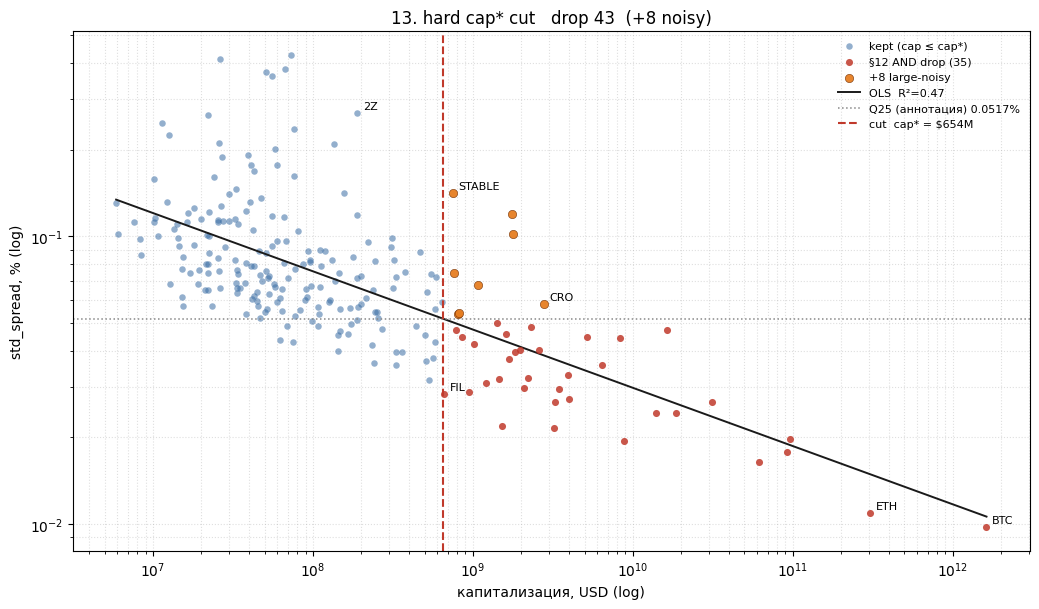

saved /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_cache/figures/scatter_capstar_hard_cut.png


In [27]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(10.5, 6.2))
x = cloud13["market_cap_usd"].to_numpy(dtype=float)
y = cloud13["std_spread"].to_numpy(dtype=float)
coins = cloud13["base_coin"].astype(str)
m35 = coins.isin(old35)
m8 = coins.isin(old8)
m_keep = ~(m35 | m8)

ax.scatter(x[m_keep], y[m_keep], s=22, c="#3b6ea5", alpha=0.55, linewidths=0, zorder=2, label="kept (cap ≤ cap*)")
ax.scatter(x[m35], y[m35], s=26, c="#c0392b", alpha=0.85, linewidths=0, zorder=3, label="§12 AND drop (35)")
ax.scatter(x[m8], y[m8], s=36, c="#e67e22", alpha=0.95, linewidths=0.4, edgecolors="#6e2c00", zorder=4, label="+8 large-noisy")

grid = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
ax.plot(grid, np.exp(ols13["a"] + ols13["b"] * np.log(grid)),
        color="#1a1a1a", lw=1.4, label=f"OLS  R²={ols13['r2']:.2f}")
ax.axhline(spec13["q_std"], color="#888", ls=":", lw=1.1, label=f"Q25 (аннотация) {spec13['q_std']:.4f}%")
ax.axvline(spec13["cap_star_usd"], color="#c0392b", ls="--", lw=1.5,
           label=f"cut  cap* = ${spec13['cap_star_usd']/1e6:.0f}M")

ax.set_xscale("log")
ax.set_yscale("log")
for _, r in cloud13.loc[cloud13["base_coin"].isin(["BTC", "ETH", "2Z", "CRO", "STABLE", "FIL"])].iterrows():
    ax.annotate(r["base_coin"], (r["market_cap_usd"], r["std_spread"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)

ax.set_xlabel("капитализация, USD (log)")
ax.set_ylabel("std_spread, % (log)")
ax.set_title(f"13. hard cap* cut   drop {cts['dropped']}  (+8 noisy)")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "scatter_capstar_hard_cut.png", dpi=140, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved", fig_dir / "scatter_capstar_hard_cut.png")


In [28]:
out_capstar = save_capstar_filtered_csv(capstar)
print("канон CSV", out_capstar)
print("история AND", JOINT_FILTERED_CSV, "существует:", Path(JOINT_FILTERED_CSV).is_file())
print("bybit_okx_universe.csv и bot не трогали")
print()
print("канон: drop iff cap > cap*, где cap* из Q25. Это не AND по std.")
print("тихое мелкое оставлено; Z* held_out; 8 шумных гигантов сняты.")


канон CSV /Users/mishatrubik/Desktop/spread/research/data/universe_capstar_filtered.csv
история AND /Users/mishatrubik/Desktop/spread/research/data/universe_joint_q25_filtered.csv существует: True
bybit_okx_universe.csv и bot не трогали

канон: drop iff cap > cap*, где cap* из Q25. Это не AND по std.
тихое мелкое оставлено; Z* held_out; 8 шумных гигантов сняты.
